# imports

In [1]:
# Standard library
from contextlib import contextmanager
from pathlib import Path
from typing import Iterable, Optional, Sequence, Tuple, Union

# Third-party
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np
import pandas as pd


# Paths and files lists

In [2]:
urban_dir = Path(r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion")
wet_dir   = Path(r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles")

urbanization_files = [
    ('urbanization_1_0.pkl', '38%'),
    ('urbanization_1_1.pkl', '42%'),
    ('urbanization_1_2.pkl', '46%'),
    ('urbanization_1_3.pkl', '49%'),
    ('urbanization_1_4.pkl', '53%'),
    ('urbanization_1_5.pkl', '57%'),
    ('urbanization_2_0.pkl', '73%'),
    ('urbanization_3_0.pkl', '81%'),
    ('urbanization_4_0.pkl', '83%'),
    ('urbanization_5_0.pkl', '87%'),
]

wet_area_files = sorted(wet_dir.glob("wet_area_summary_*.pkl"))

# keys used for merge
KEY_COLUMNS = ['event_num', 'x', 'y', 'd']

# analytical columns base names
DISCHARGE_COLUMNS = [
    ('historical', 'basin discharge', 'total_discharge'),
    ('historical', 'basin discharge', 'max_discharge'),
    ('future',     'basin discharge', 'total_discharge'),
    ('future',     'basin discharge', 'max_discharge'),
]
WET_COLUMNS_BASE = [
    ('historical', 'spatial_rain', 'wet_area_percent_mean'),
    ('future',     'spatial_rain', 'wet_area_percent_mean'),
]

# Functions

In [3]:
def ensure_multiindex(df: pd.DataFrame) -> pd.DataFrame:
    """Convert flat 'a|b|c' columns into proper MultiIndex if needed."""
    if isinstance(df.columns, pd.MultiIndex):
        return df
    new_cols = []
    for col in df.columns:
        if isinstance(col, str) and '|' in col:
            new_cols.append(tuple(col.split('|')))
        else:
            new_cols.append((col, '', ''))
    df.columns = pd.MultiIndex.from_tuples(new_cols)
    return df

def normalize_key_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add normalized merge keys (event_num, x, y, d) as flat columns."""
    out = df.copy()
    col = ('event_num', '', '') if isinstance(out.columns, pd.MultiIndex) else 'event_num'
    out['event_num'] = out[col].astype(str).str.zfill(2)
    for k in ['x', 'y', 'd']:
        c = (k, '', '') if isinstance(out.columns, pd.MultiIndex) else k
        out[k] = pd.to_numeric(out[c], errors='coerce').round().astype('Int64')
    return out

def sort_mi_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Lexsort MultiIndex columns to help Pandas perform better."""
    if isinstance(df.columns, pd.MultiIndex):
        return df.sort_index(axis=1)
    return df

def tag_top_level(df: pd.DataFrame, tag: str) -> pd.DataFrame:
    """
    Tag the top level to mark the source before merge.
    Example: 'historical' -> 'historical_urb' if tag='urb', or 'historical_wet' if tag='wet'.
    """
    if not isinstance(df.columns, pd.MultiIndex):
        return df
    new_cols = []
    for a, b, c in df.columns:
        if a in ('historical', 'future'):
            new_cols.append((f"{a}_{tag}", b, c))
        else:
            new_cols.append((a, b, c))
    out = df.copy()
    out.columns = pd.MultiIndex.from_tuples(new_cols)
    return out

def strip_suffixes(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse 'historical_x/y/urb/wet' -> 'historical', same for 'future'."""
    if not isinstance(df.columns, pd.MultiIndex):
        return df
    new_cols = []
    for a, b, c in df.columns:
        if isinstance(a, str):
            if a.startswith('historical_') or a in ('historical_x', 'historical_y'):
                a = 'historical'
            elif a.startswith('future_') or a in ('future_x', 'future_y'):
                a = 'future'
        new_cols.append((a, b, c))
    out = df.copy()
    out.columns = pd.MultiIndex.from_tuples(new_cols)
    return out

def resolve_column(df: pd.DataFrame, wanted: tuple, prefer: Optional[str] = None):
    """
    Find a MultiIndex column with flexible suffix handling.
    prefer can be 'wet' or 'urb' to try that source first.
    """
    if isinstance(df.columns, pd.MultiIndex) and wanted in df.columns:
        return wanted

    top, *rest = wanted
    rest = tuple(rest)
    suffix_order = ['_wet', '_urb', '_x', '_y'] if prefer == 'wet' else \
                   ['_urb', '_wet', '_x', '_y'] if prefer == 'urb' else \
                   ['_wet', '_urb', '_x', '_y']
    if isinstance(df.columns, pd.MultiIndex):
        for suf in suffix_order:
            cand = (f"{top}{suf}",) + rest
            if cand in df.columns:
                return cand
    else:
        flat = "|".join([str(x) for x in wanted if x])
        for c in df.columns:
            if flat in str(c):
                return c
    return None

def set_final_column_order(df: pd.DataFrame) -> pd.DataFrame:
    """
    Final order: y, d, event_num, then meta, then historical group, then future group.
    Also drop 'x' if present.
    """
    df = df.copy()
    x_col = ('x', '', '') if isinstance(df.columns, pd.MultiIndex) else 'x'
    df = df.drop(columns=[x_col], errors='ignore')

    key_order  = [('y', '', ''), ('d', '', ''), ('event_num', '', '')]
    meta_order = [('urbanization', '', ''), ('threshold', '', '')]
    hist_order = [
        ('historical', 'basin discharge', 'total_discharge'),
        ('historical', 'basin discharge', 'max_discharge'),
        ('historical', 'spatial_rain',    'wet_area_percent_mean'),
        ('historical', 'spatial_rain',    'wet_area_percent_max'),
    ]
    fut_order  = [
        ('future', 'basin discharge', 'total_discharge'),
        ('future', 'basin discharge', 'max_discharge'),
        ('future', 'spatial_rain',    'wet_area_percent_mean'),
        ('future', 'spatial_rain',    'wet_area_percent_max'),
    ]

    final_order = (
        [c for c in key_order  if c in df.columns] +
        [c for c in meta_order if c in df.columns] +
        [c for c in hist_order if c in df.columns] +
        [c for c in fut_order  if c in df.columns]
    )
    return df.loc[:, final_order]

# Load the data set

 it creates "wet_by_threshold" - dict dataset that is combination of wet area precentage and runoff data over few urbanization levels

In [4]:
# 1) Build: wet_by_threshold[threshold] = merged DF across all urbanizations
wet_by_threshold: dict[str, pd.DataFrame] = {}

for wet_path in wet_area_files:
    threshold_key = wet_path.stem.split("_")[-1]  # already in mm hr^-1 per your note
    wet_df = ensure_multiindex(pd.read_pickle(wet_path))
    wet_df = sort_mi_cols(wet_df)
    wet_df = normalize_key_columns(wet_df)
    wet_df = tag_top_level(wet_df, 'wet')  # mark source of wet columns

    have_hist_max = ('historical_wet', 'spatial_rain', 'wet_area_percent_max') in wet_df.columns
    have_fut_max  = ('future_wet',     'spatial_rain', 'wet_area_percent_max') in wet_df.columns

    wanted_wet_cols = list(WET_COLUMNS_BASE)
    if have_hist_max: wanted_wet_cols.append(('historical', 'spatial_rain', 'wet_area_percent_max'))
    if have_fut_max:  wanted_wet_cols.append(('future',     'spatial_rain', 'wet_area_percent_max'))
    if not (have_hist_max and have_fut_max):
        print(f"[INFO] threshold={threshold_key}: 'wet_area_percent_max' missing in wet pickle "
              f"(hist={have_hist_max}, fut={have_fut_max}).")

    merged_rows = []

    for fname, urb_label in urbanization_files:
        urb_path = urban_dir / fname
        if not urb_path.exists():
            print(f"[WARN] missing urbanization file: {fname}")
            continue

        urb_df = ensure_multiindex(pd.read_pickle(urb_path))
        urb_df = sort_mi_cols(urb_df)
        urb_df = normalize_key_columns(urb_df)
        urb_df = tag_top_level(urb_df, 'urb')  # mark source of discharge columns

        merged = pd.merge(
            urb_df, wet_df,
            on=KEY_COLUMNS,
            how='inner',
            validate='one_to_one'
        )
        if merged.empty:
            print(f"[WARN] empty merge at threshold={threshold_key}, urbanization={urb_label}")
            continue

        merged = ensure_multiindex(merged)

        # choose keys + discharge from URB + wet from WET
        final_cols = [(k, '', '') for k in KEY_COLUMNS]

        for tpl in DISCHARGE_COLUMNS:
            col = resolve_column(merged, tpl, prefer='urb')
            if col is not None:
                final_cols.append(col)

        for tpl in wanted_wet_cols:
            col = resolve_column(merged, tpl, prefer='wet')
            if col is not None:
                final_cols.append(col)

        merged = merged.loc[:, [c for c in final_cols if c in merged.columns]].copy()
        merged = strip_suffixes(merged)

        merged[('urbanization', '', '')] = urb_label
        merged[('threshold',    '', '')] = threshold_key

        merged_rows.append(merged)

    if merged_rows:
        combined = pd.concat(merged_rows, ignore_index=True)
        combined = set_final_column_order(combined)  # y, d, event_num, meta, hist, fut
        wet_by_threshold[threshold_key] = combined
    else:
        print(f"[WARN] no data for threshold {threshold_key}")


# 2) Build wet_abs = tidy summary per threshold × scenario × urbanization
#    Units note: thresholds are already mm hr^-1 so we keep them as-is
abs_rows = []

for thr_key, df_thr in wet_by_threshold.items():
    thr_mm_hr = float(str(thr_key).replace("_", "."))  # no *6

    for scen in ("historical", "future"):
        has_mean = (scen, "spatial_rain", "wet_area_percent_mean") in df_thr.columns
        has_max  = (scen, "spatial_rain", "wet_area_percent_max")  in df_thr.columns

        for urb, g in df_thr.groupby(("urbanization", "", "")):
            if has_mean:
                s = pd.to_numeric(g[(scen, "spatial_rain", "wet_area_percent_mean")], errors="coerce").dropna()
                if s.size:
                    abs_rows.append({
                        "threshold_mm_hr": thr_mm_hr,
                        "urbanization": urb,
                        "scenario": scen,
                        "wet_metric": "mean",
                        "n": int(s.size),
                        "median": float(np.nanmedian(s)),
                        "p25": float(np.nanpercentile(s, 25)),
                        "p75": float(np.nanpercentile(s, 75)),
                    })
            if has_max:
                s = pd.to_numeric(g[(scen, "spatial_rain", "wet_area_percent_max")], errors="coerce").dropna()
                if s.size:
                    abs_rows.append({
                        "threshold_mm_hr": thr_mm_hr,
                        "urbanization": urb,
                        "scenario": scen,
                        "wet_metric": "max",
                        "n": int(s.size),
                        "median": float(np.nanmedian(s)),
                        "p25": float(np.nanpercentile(s, 25)),
                        "p75": float(np.nanpercentile(s, 75)),
                    })

wet_abs = (
    pd.DataFrame(abs_rows)
      .sort_values(["scenario", "wet_metric", "urbanization", "threshold_mm_hr"])
      .reset_index(drop=True)
)



## KOKOS

In [5]:

# 1) Build a tidy per row table with clear names (historic vs future)
def build_event_level_pairs(
    wet_by_threshold: dict[str, pd.DataFrame],
    wet_metric: str = "mean",                      # "mean" or "max"
    threshold_filter: Optional[Sequence[Union[str, float, int]]] = None,
    urbanization_filter: Optional[Sequence[str]] = None,
    use_percent: bool = True,
    deduplicate_across_urbanization: bool = True
) -> pd.DataFrame:
    """
    Returns a tidy DataFrame where each row is one observation (event and Y-offset).
    Columns: rain_threshold_mm_per_hr, event_id, y_offset, offset_id,
             urbanization, historic_cover, future_cover
    """
    assert wet_metric in ("mean", "max")

    # normalize threshold_filter if provided
    allowed_thresholds = None
    if threshold_filter is not None:
        vals: list[float] = []
        for t in threshold_filter:
            vals.append(float(t) if isinstance(t, (int, float)) else float(str(t).replace("_", ".").strip()))
        allowed_thresholds = {round(v, 6) for v in vals}

    historical_col_key = ("historical", "spatial_rain", f"wet_area_percent_{wet_metric}")
    future_col_key     = ("future",     "spatial_rain", f"wet_area_percent_{wet_metric}")

    result_rows: list[pd.DataFrame] = []

    for threshold_key, df_threshold in wet_by_threshold.items():
        threshold_value = float(str(threshold_key).replace("_", "."))
        if allowed_thresholds is not None and round(threshold_value, 6) not in allowed_thresholds:
            continue
        if historical_col_key not in df_threshold.columns or future_col_key not in df_threshold.columns:
            continue

        frame = df_threshold.copy()

        required_cols = [
            ("event_num", "", ""), ("y", "", ""), ("d", "", ""),
            ("urbanization", "", ""), historical_col_key, future_col_key
        ]
        required_cols = [c for c in required_cols if c in frame.columns]
        frame = frame.loc[:, required_cols].copy()

        # flatten MultiIndex columns to simple strings
        flat_cols = []
        for c in frame.columns:
            if isinstance(c, tuple) and len(c) == 3 and c[1] == c[2] == "":
                flat_cols.append(c[0])
            elif isinstance(c, tuple):
                flat_cols.append("|".join(c))
            else:
                flat_cols.append(c)
        frame.columns = flat_cols

        # avoid name clash and rename to intuitive names
        if "y" in frame.columns:
            frame = frame.rename(columns={"y": "y_offset"})
        if "d" in frame.columns:
            frame = frame.rename(columns={"d": "offset_id"})

        if urbanization_filter is not None and "urbanization" in frame.columns:
            frame = frame[frame["urbanization"].isin(urbanization_filter)]

        frame["historic_cover"] = pd.to_numeric(
            frame[f"historical|spatial_rain|wet_area_percent_{wet_metric}"], errors="coerce"
        )
        frame["future_cover"] = pd.to_numeric(
            frame[f"future|spatial_rain|wet_area_percent_{wet_metric}"], errors="coerce"
        )
        frame = frame.dropna(subset=["historic_cover", "future_cover"])

        # convert fractions to percents if needed
        if use_percent and max(frame["historic_cover"].max(), frame["future_cover"].max()) <= 1.0 + 1e-9:
            frame["historic_cover"] *= 100.0
            frame["future_cover"]  *= 100.0

        frame["rain_threshold_mm_per_hr"] = threshold_value
        if "event_num" in frame.columns:
            frame["event_id"] = frame["event_num"].astype(str)
        else:
            frame["event_id"] = ""

        if deduplicate_across_urbanization:
            subset_cols = [c for c in [
                "rain_threshold_mm_per_hr", "event_id", "y_offset", "offset_id", "historic_cover", "future_cover"
            ] if c in frame.columns]
            frame = frame.sort_values(subset_cols).drop_duplicates(subset=subset_cols, keep="first")

        keep_cols = [c for c in [
            "rain_threshold_mm_per_hr", "urbanization", "event_id", "y_offset", "offset_id",
            "historic_cover", "future_cover"
        ] if c in frame.columns]
        result_rows.append(frame[keep_cols])

    if not result_rows:
        return pd.DataFrame(columns=[
            "rain_threshold_mm_per_hr", "urbanization", "event_id", "y_offset", "offset_id",
            "historic_cover", "future_cover"
        ])

    pairs = pd.concat(result_rows, ignore_index=True)
    return pairs.sort_values(["rain_threshold_mm_per_hr", "event_id"], ignore_index=True)


# 2) Normalize by threshold and prepare summaries for plotting (clear names)
def normalize_and_summarize(
    pairs: pd.DataFrame,
    center: str = "mean",          # "mean" or "median" for the big circles
    event_reduce: str = "mean"     # "mean" or "median" for per-event reduction in panel (b)
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      data_norm: input with historic_norm and future_norm (per-threshold normalization)
      means: one row per threshold with columns named by 'center'
             (historic_mean/future_mean OR historic_median/future_median)
             plus aliases historic_center/future_center for plotting compatibility
      frac_df: per threshold fraction_historic_gt_future after per-event reduction
    """
    if pairs.empty:
        raise ValueError("pairs is empty")

    center = center.lower().strip()
    if center not in {"mean", "median"}:
        raise ValueError("center must be 'mean' or 'median'")

    event_reduce = event_reduce.lower().strip()
    if event_reduce not in {"mean", "median"}:
        raise ValueError("event_reduce must be 'mean' or 'median'")

    data_norm = pairs.copy()
    data_norm["historic_norm"] = np.nan
    data_norm["future_norm"] = np.nan

    # normalize per threshold by pooled max{historic_cover, future_cover}
    for thr in np.sort(data_norm["rain_threshold_mm_per_hr"].unique()):
        sel = data_norm["rain_threshold_mm_per_hr"] == thr
        block = data_norm.loc[sel, ["historic_cover", "future_cover"]].to_numpy()
        mmax = np.nanmax(block)
        if not np.isfinite(mmax) or mmax == 0:
            continue
        data_norm.loc[sel, "historic_norm"] = data_norm.loc[sel, "historic_cover"] / mmax
        data_norm.loc[sel, "future_norm"]   = data_norm.loc[sel, "future_cover"]   / mmax

    data_norm = data_norm.dropna(subset=["historic_norm", "future_norm"])

    # center point per threshold with dynamic column names
    center_tag = "mean" if center == "mean" else "median"
    means = (
        data_norm.groupby("rain_threshold_mm_per_hr", as_index=False)
                 .agg(historic=( "historic_norm", center ),
                      future  =( "future_norm",   center ))
                 .rename(columns={
                     "historic": f"historic_{center_tag}",
                     "future":   f"future_{center_tag}",
                 })
    )
    # aliases for plotting function
    means["historic_center"] = means[f"historic_{center_tag}"]
    means["future_center"]   = means[f"future_{center_tag}"]

    # per-event reduction then fraction Historic > Future
    per_event = (
        data_norm.groupby(["rain_threshold_mm_per_hr", "event_id"], as_index=False)
                 .agg(historic_event=("historic_norm", event_reduce),
                      future_event  =("future_norm",   event_reduce))
    )
    frac_df = (
        per_event.assign(historic_gt_future=per_event["historic_event"] > per_event["future_event"])
                 .groupby("rain_threshold_mm_per_hr", as_index=False)["historic_gt_future"]
                 .mean()
                 .rename(columns={"historic_gt_future": "fraction_historic_gt_future"})
    )

    return data_norm, means, frac_df


# 3) Make the figure (expects the clear names above)
def plot_areal_coverage_changes(
    data: pd.DataFrame,
    means: pd.DataFrame,
    frac_df: pd.DataFrame,
    title: str = "Changes in areal coverage for rain rate thresholds",
    cmap_name: str = "viridis",
    point_size: int = 28,
    point_alpha: float = 0.35,
    mean_size: int = 220,
    mean_edgecolor: str = "white",
    mean_edgewidth: float = 1.8,
    show_inset: bool = True,
    inset_xlim: tuple[float, float] = (0.0, 0.03),
    inset_ylim: tuple[float, float] = (0.0, 0.03),
    # continuous X for panel (b)
    use_log_x: Optional[bool] = None,
    marker_size_b: int = 46,
    line_width_b: float = 1.6,
    # white dashed path through the big circles
    connect_means: bool = True,
    mean_path_color: str = "white",
    mean_path_lw: float = 2.2,
    mean_path_ls: str = "--",
    draw_mean_path_in_inset: bool = True
):
    """
    Left panel: scatter of normalized pairs with mean/median circles.
    Right panel: fraction of events where historic > future vs. continuous threshold (log x optional).
    """
    if data.empty or means.empty or frac_df.empty:
        raise ValueError("input frames are empty")

    thresholds = np.sort(data["rain_threshold_mm_per_hr"].unique().astype(float))
    cmap = plt.cm.get_cmap(cmap_name)
    vmin, vmax = float(thresholds.min()), float(thresholds.max())
    if vmin == vmax:
        vmax = vmin + 1e-9
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def color_for(threshold: float):
        return cmap(norm(float(threshold)))

    fig, axs = plt.subplots(1, 2, figsize=(12, 5.5), dpi=150)

    # left panel
    ax = axs[0]
    for threshold in thresholds:
        sub = data[data["rain_threshold_mm_per_hr"] == threshold]
        ax.scatter(sub["historic_norm"], sub["future_norm"],
                   s=point_size, alpha=point_alpha, edgecolors="none",
                   c=[color_for(threshold)])

    # mean/median circles with white outline
    for _, row in means.iterrows():
        threshold = float(row["rain_threshold_mm_per_hr"])
        ax.scatter([row["historic_center"]], [row["future_center"]],
                   s=mean_size, facecolors=color_for(threshold),
                   edgecolors=mean_edgecolor, linewidths=mean_edgewidth, zorder=6)

    # dashed path through the big circles
    if connect_means and len(means) >= 2:
        ms = means.sort_values("rain_threshold_mm_per_hr")
        ax.plot(ms["historic_center"].to_numpy(), ms["future_center"].to_numpy(),
                color=mean_path_color, lw=mean_path_lw, ls=mean_path_ls, zorder=7, alpha=0.95)

    # identity line and axes
    ax.plot([0, 1], [0, 1], color="black", lw=3.0, linestyle=(0, (4, 2)), alpha=0.9)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Normalized mean cover: Historical")
    ax.set_ylabel("Normalized mean cover: Future")
    ax.set_title("(a) Areal mean coverage per event")
    ax.grid(True, alpha=0.25)

    # colorbar
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Rain threshold [mm h\u207B\u00B9]")

    # inset zoom
    if show_inset:
        axins = inset_axes(ax, width="38%", height="38%", loc="lower right", borderpad=0.6)
        for threshold in thresholds:
            sub = data[data["rain_threshold_mm_per_hr"] == threshold]
            axins.scatter(sub["historic_norm"], sub["future_norm"],
                          s=point_size * 0.8, alpha=0.55, edgecolors="none",
                          c=[color_for(threshold)])
        for _, row in means.iterrows():
            threshold = float(row["rain_threshold_mm_per_hr"])
            axins.scatter([row["historic_center"]], [row["future_center"]],
                          s=max(10, mean_size * 0.75),
                          facecolors=color_for(threshold),
                          edgecolors="white", linewidths=1.4, zorder=7)

        if draw_mean_path_in_inset and connect_means and len(means) >= 2:
            ms = means.sort_values("rain_threshold_mm_per_hr")
            axins.plot(ms["historic_center"].to_numpy(), ms["future_center"].to_numpy(),
                       color=mean_path_color, lw=max(1.5, mean_path_lw * 0.8),
                       ls=mean_path_ls, zorder=8, alpha=0.95)

        axins.plot([0, 1], [0, 1], color="black", lw=2.0, linestyle=(0, (4, 2)), alpha=0.9)
        axins.set_xlim(*inset_xlim)
        axins.set_ylim(*inset_ylim)
        axins.grid(True, alpha=0.15)
        axins.tick_params(labelsize=8)
        try:
            ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=1.2)
        except Exception:
            mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="black", lw=1.2)

    # right panel — continuous x axis
    axb = axs[1]
    share_vals = []
    for threshold in thresholds:
        v = frac_df.loc[
            np.isclose(frac_df["rain_threshold_mm_per_hr"].astype(float), threshold, atol=1e-9),
            "fraction_historic_gt_future"
        ].values
        share_vals.append(float(v[0]) if len(v) else np.nan)
    share_vals = np.asarray(share_vals, float)

    # choose log x automatically if dynamic range is large, or by request
    if use_log_x is None:
        pos = thresholds[thresholds > 0]
        auto_log = len(pos) >= 2 and (pos.max() / max(pos.min(), 1e-12) >= 20)
    else:
        auto_log = bool(use_log_x)
    if auto_log:
        axb.set_xscale("log")

    axb.plot(thresholds, share_vals, color="0.25", lw=line_width_b, zorder=2)
    axb.scatter(thresholds, share_vals, s=marker_size_b,
                c=[color_for(t) for t in thresholds],
                edgecolors=(0, 0, 0, 0.5), linewidths=0.6, zorder=3)

    if len(thresholds) <= 12:
        axb.set_xticks(thresholds)
        axb.set_xticklabels([f"{t:g}" for t in thresholds])

    axb.set_ylim(0, 1.0)
    axb.set_ylabel("Fraction of events with larger Historical coverage")
    axb.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    axb.set_title("(b) Historical larger than Future")
    axb.grid(True, axis="y", alpha=0.25)
    if auto_log:
        axb.grid(True, axis="x", which="both", alpha=0.15)

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs


In [6]:
def normalize_and_summarize(
    pairs: pd.DataFrame,
    center: str = "mean",          # "mean" or "median" for the big circles
    event_reduce: str = "mean",     # "mean" or "median" for per-event reduction in panel (b)
    norm_method: str = "pooled_max_per_threshold"  # "global_hist_max" or "hist_max_per_threshold" or default
) -> tuple:
    """
    norm_method options:
      - "pooled_max_per_threshold"  (your current behavior): for each threshold, divide by max of {historic, future} within that threshold
      - "global_hist_max": divide all rows by the single global max of historic_cover across the whole dataset
      - "hist_max_per_threshold": for each threshold, divide by the max of historic_cover within that threshold

    Returns:
      data_norm: input with historic_norm and future_norm after normalization
      means: one row per threshold with columns historic_center and future_center (plus historic_mean/median etc.)
      frac_df: per threshold fraction_historic_gt_future after per-event reduction
    """
    if pairs.empty:
        raise ValueError("pairs is empty")

    center = center.lower().strip()
    if center not in {"mean", "median"}:
        raise ValueError("center must be 'mean' or 'median'")

    event_reduce = event_reduce.lower().strip()
    if event_reduce not in {"mean", "median"}:
        raise ValueError("event_reduce must be 'mean' or 'median'")

    method = norm_method.lower().strip()
    if method not in {"pooled_max_per_threshold", "global_hist_max", "hist_max_per_threshold"}:
        raise ValueError("norm_method must be one of 'pooled_max_per_threshold', 'global_hist_max', 'hist_max_per_threshold'")

    data_norm = pairs.copy()
    data_norm["historic_norm"] = np.nan
    data_norm["future_norm"] = np.nan

    # choose denominators according to the requested method
    if method == "global_hist_max":
        # single global denominator from historic only
        denom = pd.to_numeric(data_norm["historic_cover"], errors="coerce").max()
        if not np.isfinite(denom) or denom == 0:
            raise ValueError("global historic max is not finite or zero")
        data_norm["historic_norm"] = data_norm["historic_cover"] / denom
        data_norm["future_norm"]   = data_norm["future_cover"]  / denom

    elif method == "hist_max_per_threshold":
        # per-threshold denominator from historic only
        for thr in np.sort(data_norm["rain_threshold_mm_per_hr"].unique()):
            sel = data_norm["rain_threshold_mm_per_hr"] == thr
            denom = pd.to_numeric(data_norm.loc[sel, "historic_cover"], errors="coerce").max()
            if np.isfinite(denom) and denom > 0:
                data_norm.loc[sel, "historic_norm"] = data_norm.loc[sel, "historic_cover"] / denom
                data_norm.loc[sel, "future_norm"]   = data_norm.loc[sel, "future_cover"]  / denom

    else:
        # original behavior: per-threshold pooled max of historic and future
        for thr in np.sort(data_norm["rain_threshold_mm_per_hr"].unique()):
            sel = data_norm["rain_threshold_mm_per_hr"] == thr
            block = data_norm.loc[sel, ["historic_cover", "future_cover"]].to_numpy(dtype=float)
            mmax = np.nanmax(block)
            if np.isfinite(mmax) and mmax > 0:
                data_norm.loc[sel, "historic_norm"] = data_norm.loc[sel, "historic_cover"] / mmax
                data_norm.loc[sel, "future_norm"]   = data_norm.loc[sel, "future_cover"]  / mmax

    data_norm = data_norm.dropna(subset=["historic_norm", "future_norm"])

    # center point per threshold with dynamic column names
    center_tag = "mean" if center == "mean" else "median"
    means = (
        data_norm.groupby("rain_threshold_mm_per_hr", as_index=False)
                 .agg(historic=("historic_norm", center),
                      future  =("future_norm",   center))
                 .rename(columns={
                     "historic": f"historic_{center_tag}",
                     "future":   f"future_{center_tag}",
                 })
    )
    # aliases for plotting compatibility
    means["historic_center"] = means[f"historic_{center_tag}"]
    means["future_center"]   = means[f"future_{center_tag}"]

    # per-event reduction then fraction Historic > Future
    per_event = (
        data_norm.groupby(["rain_threshold_mm_per_hr", "event_id"], as_index=False)
                 .agg(historic_event=("historic_norm", event_reduce),
                      future_event  =("future_norm",   event_reduce))
    )
    frac_df = (
        per_event.assign(historic_gt_future=per_event["historic_event"] > per_event["future_event"])
                 .groupby("rain_threshold_mm_per_hr", as_index=False)["historic_gt_future"]
                 .mean()
                 .rename(columns={"historic_gt_future": "fraction_historic_gt_future"})
    )

    return data_norm, means, frac_df


## Data process

In [7]:
pairs = build_event_level_pairs(
    wet_by_threshold,
    wet_metric="mean",
    threshold_filter=[0.1, 1, 2, 5, 10, 20, 50, 60, 80]
)

data_norm, means, frac_df = normalize_and_summarize(pairs)

In [8]:
data_norm

,rain_threshold_mm_per_hr,urbanization,event_id,y_offset,offset_id,historic_cover,future_cover,historic_norm,future_norm
0,0.1,38%,01,-20000,20000,27.040207,12.528695,0.549802,0.254743
1,0.1,38%,01,-19500,19500,27.264011,12.322054,0.554353,0.250541
2,0.1,38%,01,-19000,19000,27.768091,12.368041,0.564602,0.251476
3,0.1,38%,01,-18500,18500,27.922344,12.327636,0.567738,0.250655
4,0.1,38%,01,-18000,18000,28.388191,12.391782,0.577210,0.251959
...,...,...,...,...,...,...,...,...,...
26563,80.0,38%,41,18000,18000,0.000000,0.000000,0.000000,0.000000
26564,80.0,38%,41,18500,18500,0.000000,0.000000,0.000000,0.000000
26565,80.0,38%,41,19000,19000,0.000000,0.000000,0.000000,0.000000
26566,80.0,38%,41,19500,19500,0.000000,0.000000,0.000000,0.000000


In [9]:
means

,rain_threshold_mm_per_hr,historic_mean,future_mean,historic_center,future_center
0,0.1,0.352389,0.252642,0.352389,0.252642
1,1.0,0.264945,0.190120,0.264945,0.190120
2,5.0,0.176238,0.141956,0.176238,0.141956
3,10.0,0.169021,0.161317,0.169021,0.161317
4,20.0,0.132923,0.148727,0.132923,0.148727
5,50.0,0.029312,0.027685,0.029312,0.027685
6,60.0,0.012305,0.012158,0.012305,0.012158
7,80.0,0.003915,0.004845,0.003915,0.004845


In [10]:
frac_df

,rain_threshold_mm_per_hr,fraction_historic_gt_future
0,0.1,0.878049
1,1.0,0.853659
2,5.0,0.707317
3,10.0,0.536585
4,20.0,0.390244
5,50.0,0.121951
6,60.0,0.170732
7,80.0,0.048780


## Time to plot

In [11]:
pairs = build_event_level_pairs(
    wet_by_threshold,
    wet_metric="mean",
    threshold_filter=[0.1, 1, 5, 10, 20, 40, 80]
)

data_norm, means, frac_df = normalize_and_summarize(pairs)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Tuple
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import cm

# ---------- helpers ----------

def _means_to_percent(means: pd.DataFrame) -> pd.DataFrame:
    """Return tidy table with thresholds and mean coverage in percent."""
    m = means.loc[:, ["rain_threshold_mm_per_hr", "historic_mean", "future_mean"]].copy()
    m = m.apply(pd.to_numeric, errors="coerce").dropna().sort_values("rain_threshold_mm_per_hr")
    # fraction -> percent if needed
    max_val = float(np.nanmax([m["historic_mean"].max(), m["future_mean"].max()]))
    if np.isfinite(max_val) and max_val <= 1.0 + 1e-9:
        m["historic_pct"] = m["historic_mean"] * 100.0
        m["future_pct"]   = m["future_mean"]  * 100.0
    else:
        m["historic_pct"] = m["historic_mean"]
        m["future_pct"]   = m["future_mean"]
    m = m.rename(columns={"rain_threshold_mm_per_hr": "thr"})
    return m[["thr", "historic_pct", "future_pct"]]

def _auto_log_x(thr: np.ndarray) -> bool:
    pos = thr[thr > 0]
    return (pos.size >= 2) and (pos.max() / max(pos.min(), 1e-12) >= 20)

# color constants
COL_HIST = "#225ea8"
COL_FUT  = "#7a0177"
BAND_H   = "#9ecae1"
BAND_F   = "#f768a1"

# =====================================================================
# (1) Main figure: mean curves with a zoom-inset for 10–80 mm h^-1
# =====================================================================

def plot_mean_with_zoom(
    means: pd.DataFrame,
    title: Optional[str] = None,
    y_log: bool = True,
    inset_xlim: Tuple[float, float] = (10.0, 80.0),
    inset_size: Tuple[str, str] = ("45%", "50%"),   # width, height
    inset_loc: str = "upper right",
    y_floor: float = 0.05,                          # % floor for log
    marker_size: float = 6.0
):
    """
    Mean normalized coverage [%] vs threshold with an inset zoom over [10, 80] mm h^-1.
    - Two lines (Historic, Future)
    - Optional log Y
    - Inset shows the same style zoomed on the right-hand range.
    """
    m = _means_to_percent(means)
    thr  = m["thr"].astype(float).values
    hist = m["historic_pct"].astype(float).values
    fut  = m["future_pct"].astype(float).values

    use_logx = _auto_log_x(thr)

    fig, ax = plt.subplots(figsize=(5.6, 3.8), dpi=300)
    if use_logx: ax.set_xscale("log")
    if y_log:    ax.set_yscale("log")

    # for log y
    floor = max(y_floor, 1e-6)
    h_plot = np.where(hist > 0, hist, floor)
    f_plot = np.where(fut  > 0, fut,  floor)

    # main lines
    ax.plot(thr, h_plot, color=COL_HIST, lw=2.0, marker="o", ms=marker_size, label="Historic")
    ax.plot(thr, f_plot, color=COL_FUT,  lw=2.0, marker="o", ms=marker_size, label="Future")

    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("Mean normalized coverage [%]")
    if len(thr) <= 12:
        ax.set_xticks(thr); ax.set_xticklabels([("{:g}".format(t)) for t in thr])
    ax.grid(True, axis="y", which=("both" if y_log else "major"), alpha=0.25)
    if use_logx: ax.grid(True, axis="x", which="both", alpha=0.12)

    # legend
    ax.legend(frameon=True, framealpha=0.9, fontsize=8, loc="best")

    # inset
    axins = inset_axes(ax, width=inset_size[0], height=inset_size[1], loc=inset_loc, borderpad=0.8)
    if use_logx: axins.set_xscale("log")
    if y_log:    axins.set_yscale("log")
    axins.plot(thr, h_plot, color=COL_HIST, lw=1.6, marker="o", ms=4.5)
    axins.plot(thr, f_plot, color=COL_FUT,  lw=1.6, marker="o", ms=4.5)
    axins.set_xlim(*inset_xlim)

    # y-limits in inset: pad 15% around data in range
    msk = (thr >= inset_xlim[0]) & (thr <= inset_xlim[1])
    if np.any(msk):
        ydat = np.r_[h_plot[msk], f_plot[msk]]
        if y_log:
            ymin = float(np.nanmin(ydat[ydat > 0] if np.any(ydat > 0) else np.array([floor])))
            ymax = float(np.nanmax(ydat))
            axins.set_ylim(max(floor, ymin*0.85), ymax*1.15)
        else:
            axins.set_ylim(float(np.nanmin(ydat))*0.85, float(np.nanmax(ydat))*1.15)

    axins.grid(True, which=("both" if y_log else "major"), alpha=0.2)
    ax.indicate_inset_zoom(axins, edgecolor="0.2", linewidth=1.0)

    if title: ax.set_title(title)
    plt.tight_layout()
    return fig, (ax, axins)

# =====================================================================
# (2) Five alternative, original views of the same data
# =====================================================================

def plot_ratio_vs_threshold(means: pd.DataFrame, title: Optional[str] = None, y_log: bool = True):
    """
    Plot ratio R = Future / Historic (unitless). Emphasizes convergence/divergence.
    y=1 dashed baseline; log-y highlights deviations symmetrically around 1.
    """
    m = _means_to_percent(means)
    thr = m["thr"].astype(float).values
    hist = m["historic_pct"].astype(float).values
    fut  = m["future_pct"].astype(float).values
    R = np.divide(fut, hist, out=np.full_like(fut, np.nan), where=hist>0)

    use_logx = _auto_log_x(thr)
    fig, ax = plt.subplots(figsize=(5.0, 3.4), dpi=300)
    if use_logx: ax.set_xscale("log")
    if y_log:    ax.set_yscale("log")

    ax.axhline(1.0, color="0.35", lw=1.2, ls=(0,(4,2)))
    ax.plot(thr, R, color="#444444", lw=2.0, marker="o")
    # sign-colored fill
    above = R >= 1
    ax.fill_between(thr, 1.0, R, where=above, color=BAND_F, alpha=0.35, interpolate=True)
    ax.fill_between(thr, R, 1.0, where=~above, color=BAND_H, alpha=0.35, interpolate=True)

    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("Future / Historic  [×]")
    if len(thr) <= 12:
        ax.set_xticks(thr); ax.set_xticklabels([("{:g}".format(t)) for t in thr])
    ax.grid(True, which=("both" if (y_log or use_logx) else "major"), alpha=0.25)
    if title: ax.set_title(title)
    plt.tight_layout()
    return fig, ax

def plot_delta_vs_threshold(means: pd.DataFrame, title: Optional[str] = None,
                            symlog: bool = True, linthresh: float = 0.1):
    """
    Plot Δ% = Future − Historic as vertical bars with sign-based color.
    Optionally uses symmetric symlog y-scale around zero to reveal small/large deltas.
    """
    m = _means_to_percent(means)
    thr = m["thr"].astype(float).values
    D = (m["future_pct"] - m["historic_pct"]).astype(float).values

    use_logx = _auto_log_x(thr)
    fig, ax = plt.subplots(figsize=(5.0, 3.4), dpi=300)
    if use_logx: ax.set_xscale("log")
    if symlog:   ax.set_yscale("symlog", linthresh=linthresh)

    for x, d in zip(thr, D):
        if d >= 0:
            ax.vlines(x, 0, d, color=COL_FUT, lw=4.0)
        else:
            ax.vlines(x, d, 0, color=COL_HIST, lw=4.0)
    ax.axhline(0, color="0.35", lw=1.2, ls=(0,(4,2)))

    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("Δ mean coverage [%]  (future − historic)")
    if len(thr) <= 12:
        ax.set_xticks(thr); ax.set_xticklabels([("{:g}".format(t)) for t in thr])
    ax.grid(True, which=("both" if symlog else "major"), alpha=0.25)
    if title: ax.set_title(title)
    plt.tight_layout()
    return fig, ax

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional

# מניח שקיימים COL_HIST ו COL_FUT כמו קודם
# ומטפל גם אם יש אצלך _to_abs_percent וגם אם נשאר _means_to_percent
def _get_means_percent(means: pd.DataFrame) -> pd.DataFrame:
    try:
        m = _to_abs_percent(means)  # אם הוגדר אצלך
    except NameError:
        m = _means_to_percent(means)  # פונקציה קודמת
    return m

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional

# Fallback colors if not already defined in your session
try:
    COL_HIST
    COL_FUT
except NameError:
    COL_HIST = "#225ea8"  # blue
    COL_FUT  = "#7a0177"  # purple

def _get_means_percent(means: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy DataFrame with columns:
      'thr' (threshold), 'historic_pct', 'future_pct'
    Values are absolute mean coverage in percent.
    Uses your existing converters if present, otherwise falls back to a local one.
    """
    # Use user's existing helpers if available
    try:
        m = _to_abs_percent(means)  # user's helper (absolute percent)
        return m
    except NameError:
        try:
            m = _means_to_percent(means)  # another user's helper
            return m
        except NameError:
            pass

    # Local fallback: convert fractions (0..1) to percent if needed
    m = means.loc[:, ["rain_threshold_mm_per_hr", "historic_mean", "future_mean"]].copy()
    m = m.apply(pd.to_numeric, errors="coerce").dropna().sort_values("rain_threshold_mm_per_hr")
    max_val = float(np.nanmax([m["historic_mean"].max(), m["future_mean"].max()]))
    if np.isfinite(max_val) and max_val <= 1.0 + 1e-9:
        m["historic_pct"] = m["historic_mean"] * 100.0
        m["future_pct"]   = m["future_mean"]  * 100.0
    else:
        m["historic_pct"] = m["historic_mean"]
        m["future_pct"]   = m["future_mean"]
    m = m.rename(columns={"rain_threshold_mm_per_hr": "thr"})
    return m[["thr", "historic_pct", "future_pct"]]

def plot_dumbbell_horizontal(means: pd.DataFrame,
                             title: Optional[str] = None,
                             x_log: bool = True):
    """
    Horizontal dumbbell plot with a logarithmic Y-axis that encodes the rain threshold values.
    Each threshold is positioned on Y according to its numeric value (log scale),
    so spacing reflects ratios (e.g., 0.1 to 1 is farther than 1 to 5).

    Left dot = Historic, right dot = Future.
    The connecting segment is colored by the larger of the two.
    """
    m = _get_means_percent(means).sort_values("thr", ascending=True)

    # Guard against non-positive thresholds for log scale
    thr_vals = m["thr"].astype(float).values
    if np.any(thr_vals <= 0):
        raise ValueError("All rain thresholds must be positive for a logarithmic Y-axis.")

    hist = m["historic_pct"].astype(float).values
    fut  = m["future_pct"].astype(float).values

    fig, ax = plt.subplots(figsize=(6.4, 4.8), dpi=300)

    # Optional log X for coverage axis if your percent range spans orders of magnitude
    if x_log:
        ax.set_xscale("log")

    # Logarithmic Y to reflect threshold spacing
    ax.set_yscale("log")

    # Draw connecting segments colored by the winner for each threshold
    for yv, h, f in zip(thr_vals, hist, fut):
        col = COL_HIST if h >= f else COL_FUT
        ax.hlines(yv, min(h, f), max(h, f), colors=col, lw=3.0, alpha=0.9)

    # Scatter points for historic and future
    ax.scatter(hist, thr_vals, color=COL_HIST, s=38, zorder=3, label="Historic")
    ax.scatter(fut,  thr_vals, color=COL_FUT,  s=38, zorder=3, label="Future")

    # Y ticks exactly at threshold values, labeled by their numeric value
    ax.set_yticks(thr_vals)
    ax.set_yticklabels(["{:g}".format(t) for t in thr_vals])

    # Nice padded Y limits on log scale
    y_min, y_max = thr_vals.min(), thr_vals.max()
    ax.set_ylim(y_min * 0.9, y_max * 1.1)

    # Axis labels and grid
    ax.set_xlabel("Mean catchment coverage [%]")
    ax.set_ylabel("Rain threshold [mm h\u207B\u00B9]")
    ax.grid(True, axis="x", which=("both" if x_log else "major"), alpha=0.25)
    ax.grid(True, axis="y", which="both", alpha=0.15)

    # Legend and optional title
    ax.legend(frameon=True, framealpha=0.9, loc="lower left")
    if title is not None:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax




def plot_grouped_bars(means: pd.DataFrame, title: Optional[str] = None, y_log: bool = True):
    """
    Grouped bar chart per threshold (Historic/Future). Good for small sets and clear labels.
    """
    m = _means_to_percent(means)
    labels = m["thr"].map(lambda v: "{:g}".format(v)).tolist()
    idx = np.arange(len(m))
    w = 0.38

    fig, ax = plt.subplots(figsize=(6.0, 3.8), dpi=300)
    if y_log: ax.set_yscale("log")

    ax.bar(idx - w/2, m["historic_pct"].values, width=w, color=COL_HIST, label="Historic")
    ax.bar(idx + w/2, m["future_pct"].values,   width=w, color=COL_FUT,  label="Future")

    ax.set_xticks(idx); ax.set_xticklabels(labels)
    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("Mean normalized coverage [%]")
    ax.grid(True, axis="y", which=("both" if y_log else "major"), alpha=0.25)
    ax.legend(frameon=True, framealpha=0.9)
    if title: ax.set_title(title)
    plt.tight_layout()
    return fig, ax

def plot_heatmap_2xN(means: pd.DataFrame, title: Optional[str] = None, annotate: bool = True):
    """
    2×N heatmap: rows = [Historic, Future], columns = thresholds.
    Color encodes mean coverage [%]. Optionally annotate each cell with its value.
    """
    m = _means_to_percent(means)
    thr_lbls = m["thr"].map(lambda v: "{:g}".format(v)).tolist()
    data = np.vstack([m["historic_pct"].values, m["future_pct"].values])  # 2 x N

    fig, ax = plt.subplots(figsize=(max(5.5, 0.5*len(thr_lbls)+2.0), 2.8), dpi=300)
    im = ax.imshow(data, aspect="auto", cmap="viridis")
    ax.set_yticks([0,1]); ax.set_yticklabels(["Historic", "Future"])
    ax.set_xticks(np.arange(len(thr_lbls))); ax.set_xticklabels(thr_lbls)
    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mean normalized coverage [%]")

    if annotate:
        for i in range(2):
            for j in range(len(thr_lbls)):
                ax.text(j, i, "{:.1f}".format(data[i, j]), ha="center", va="center",
                        color="white" if data[i,j] > data.max()*0.6 else "black", fontsize=8)

    if title: ax.set_title(title)
    plt.tight_layout()
    return fig, ax


C:\Users\raznu\AppData\Local\Temp\ipykernel_37244\2129951808.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


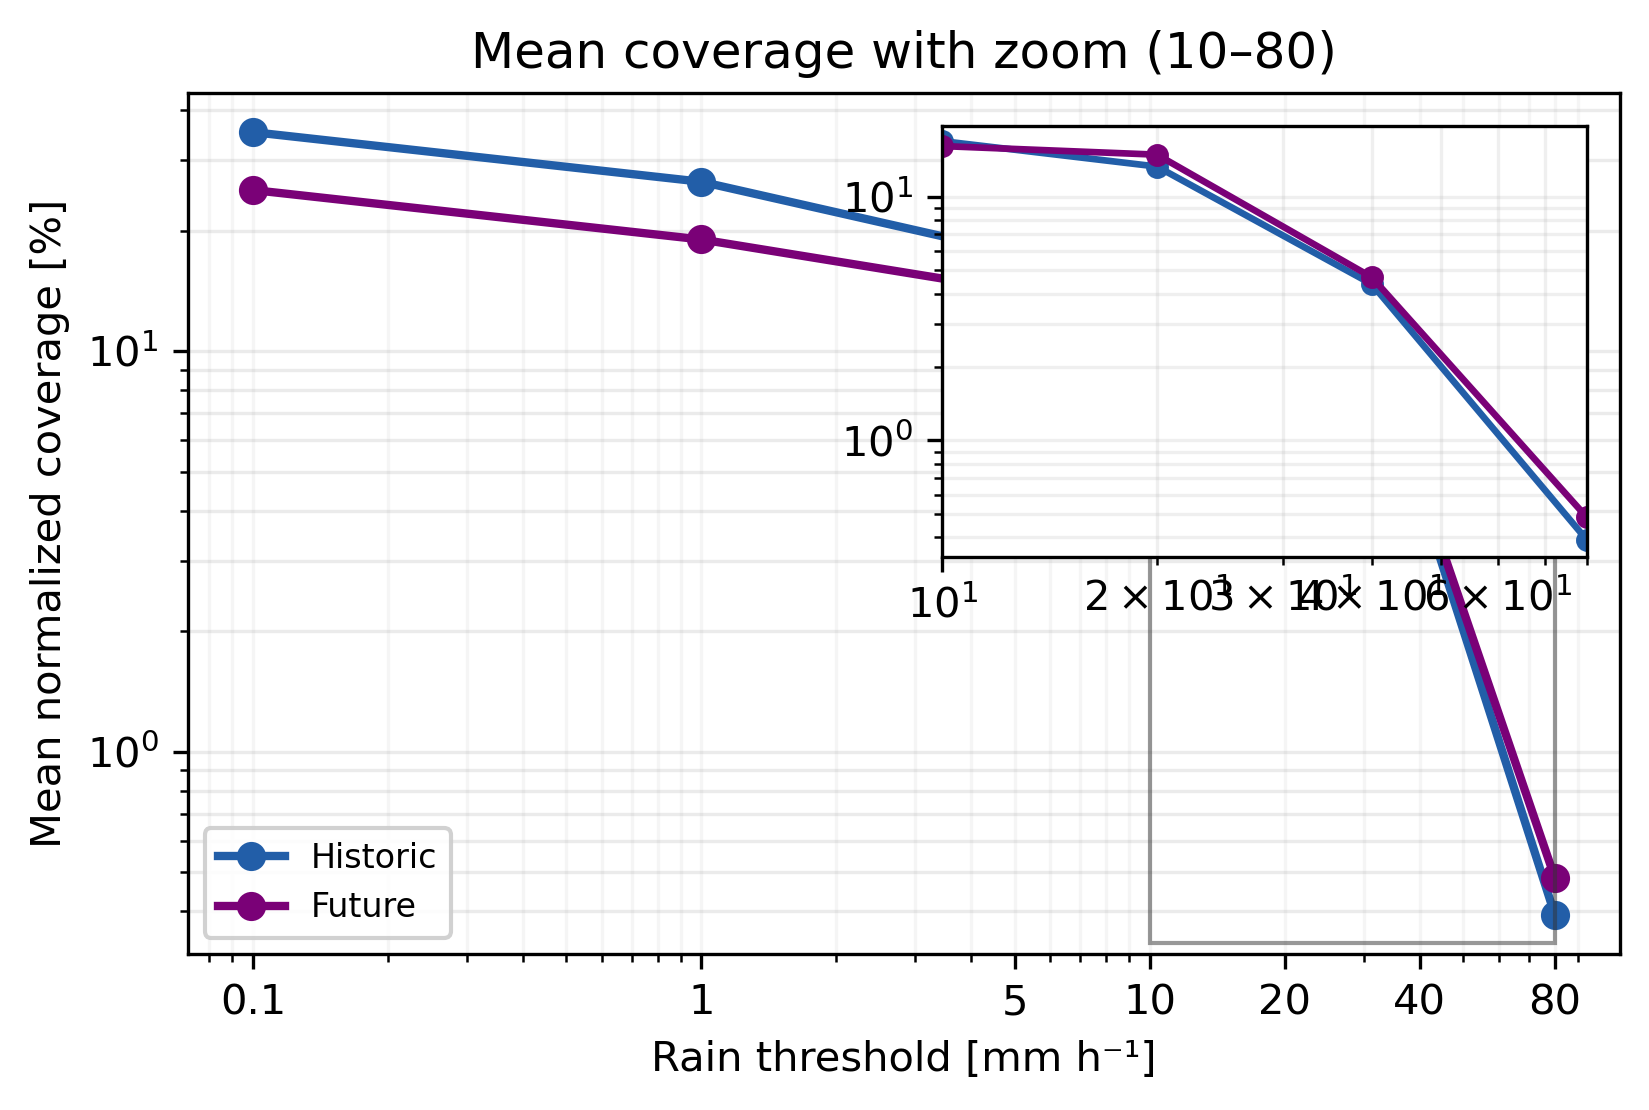

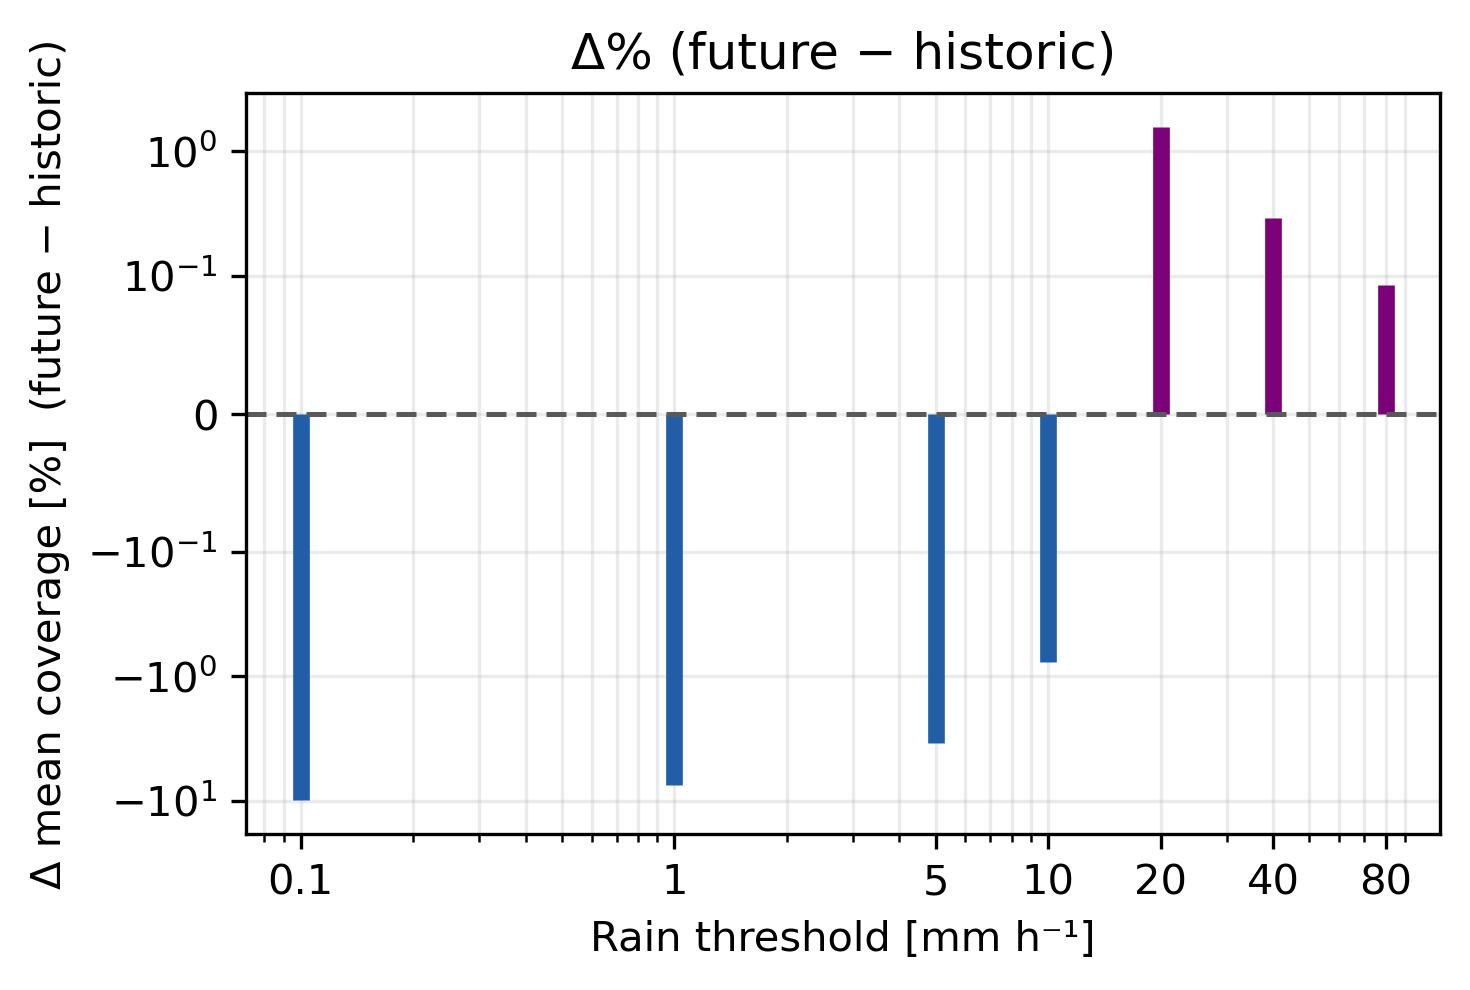

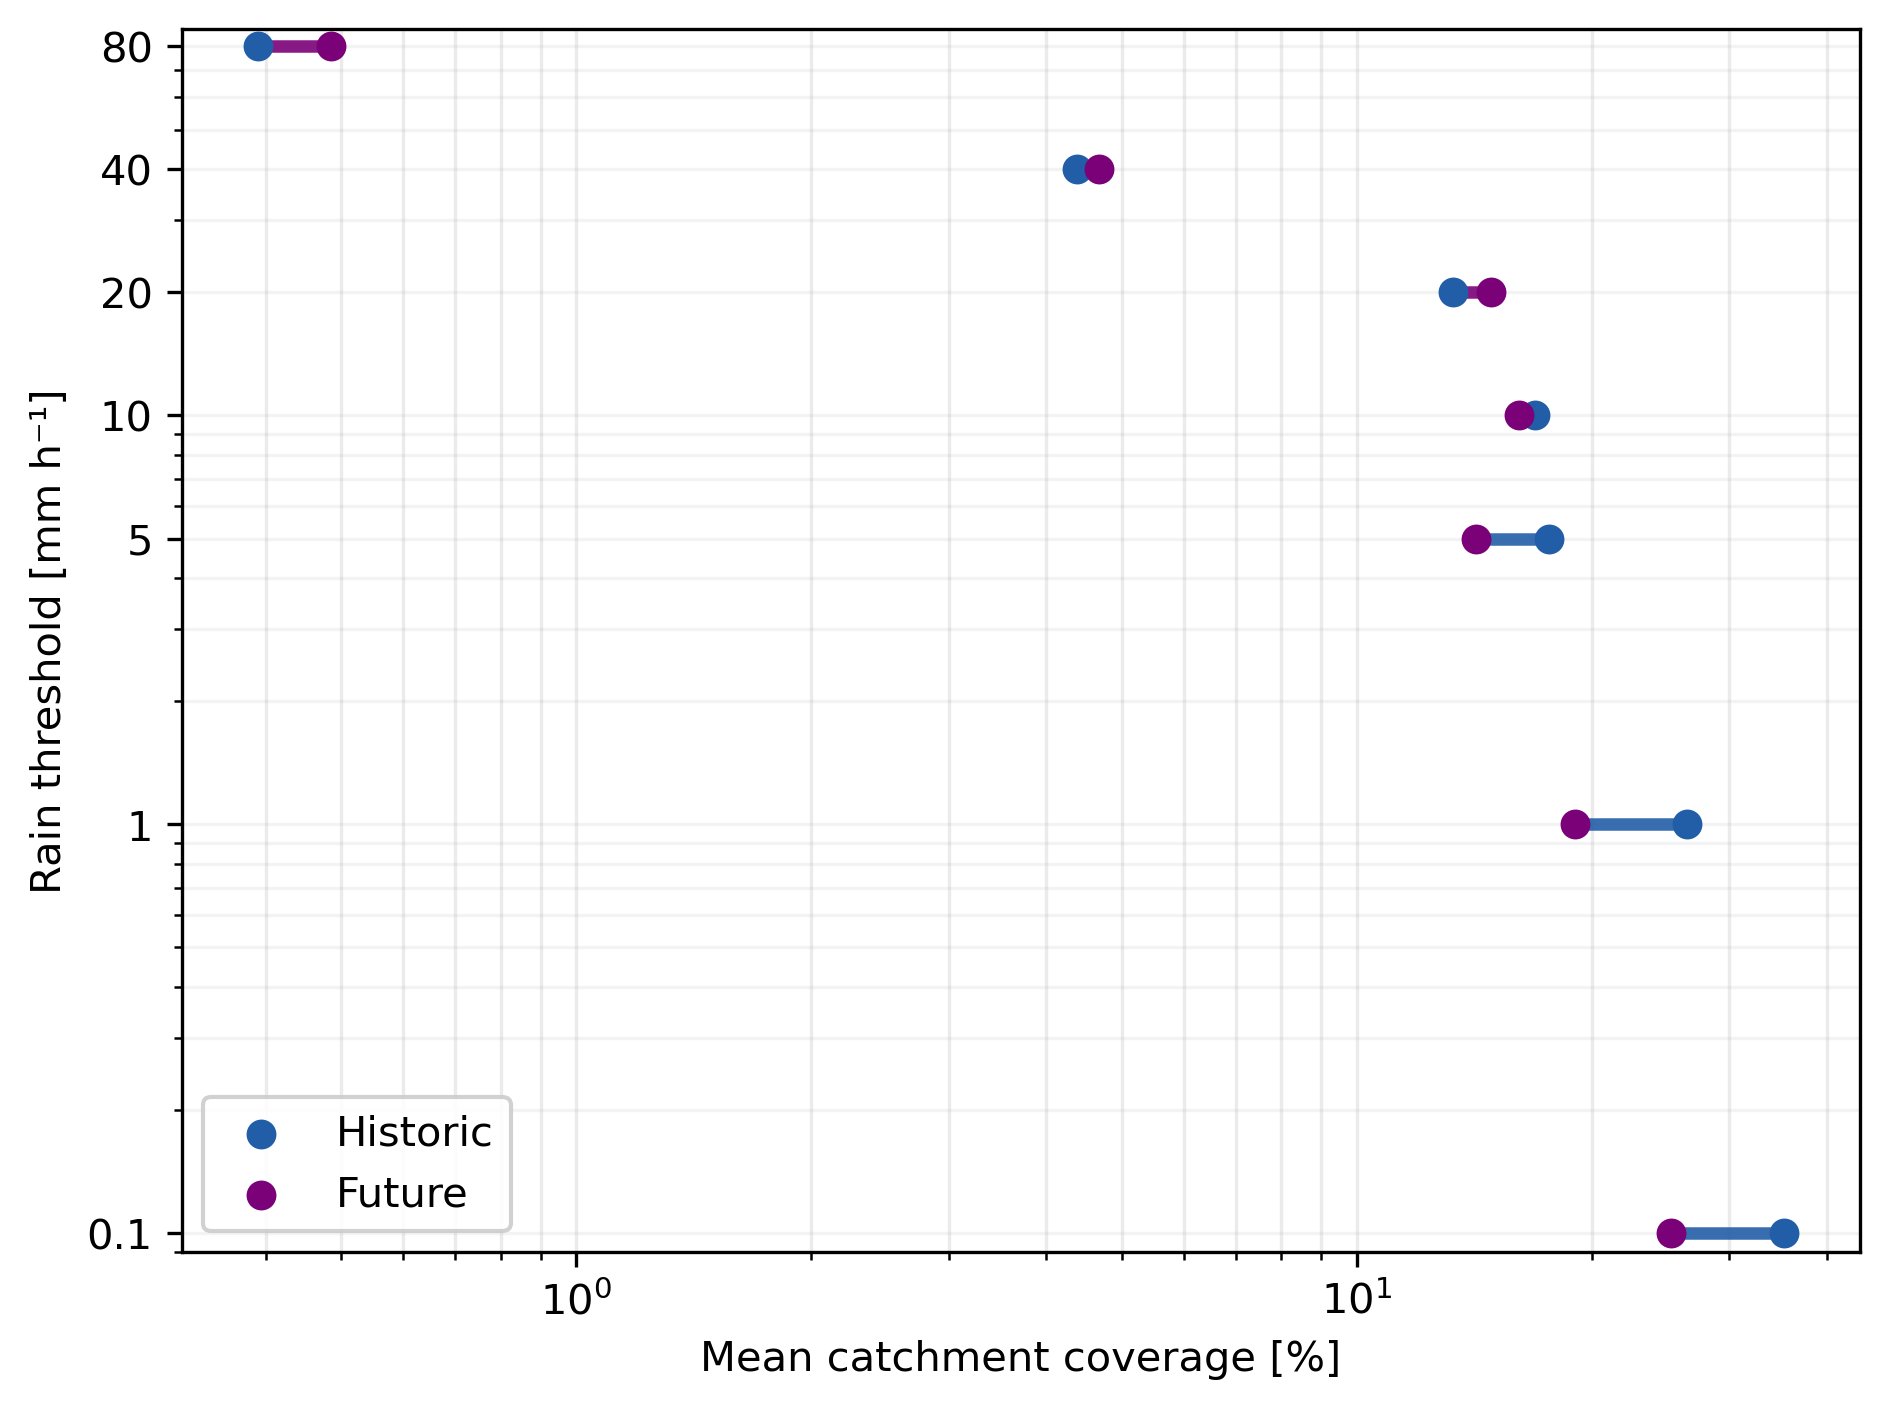

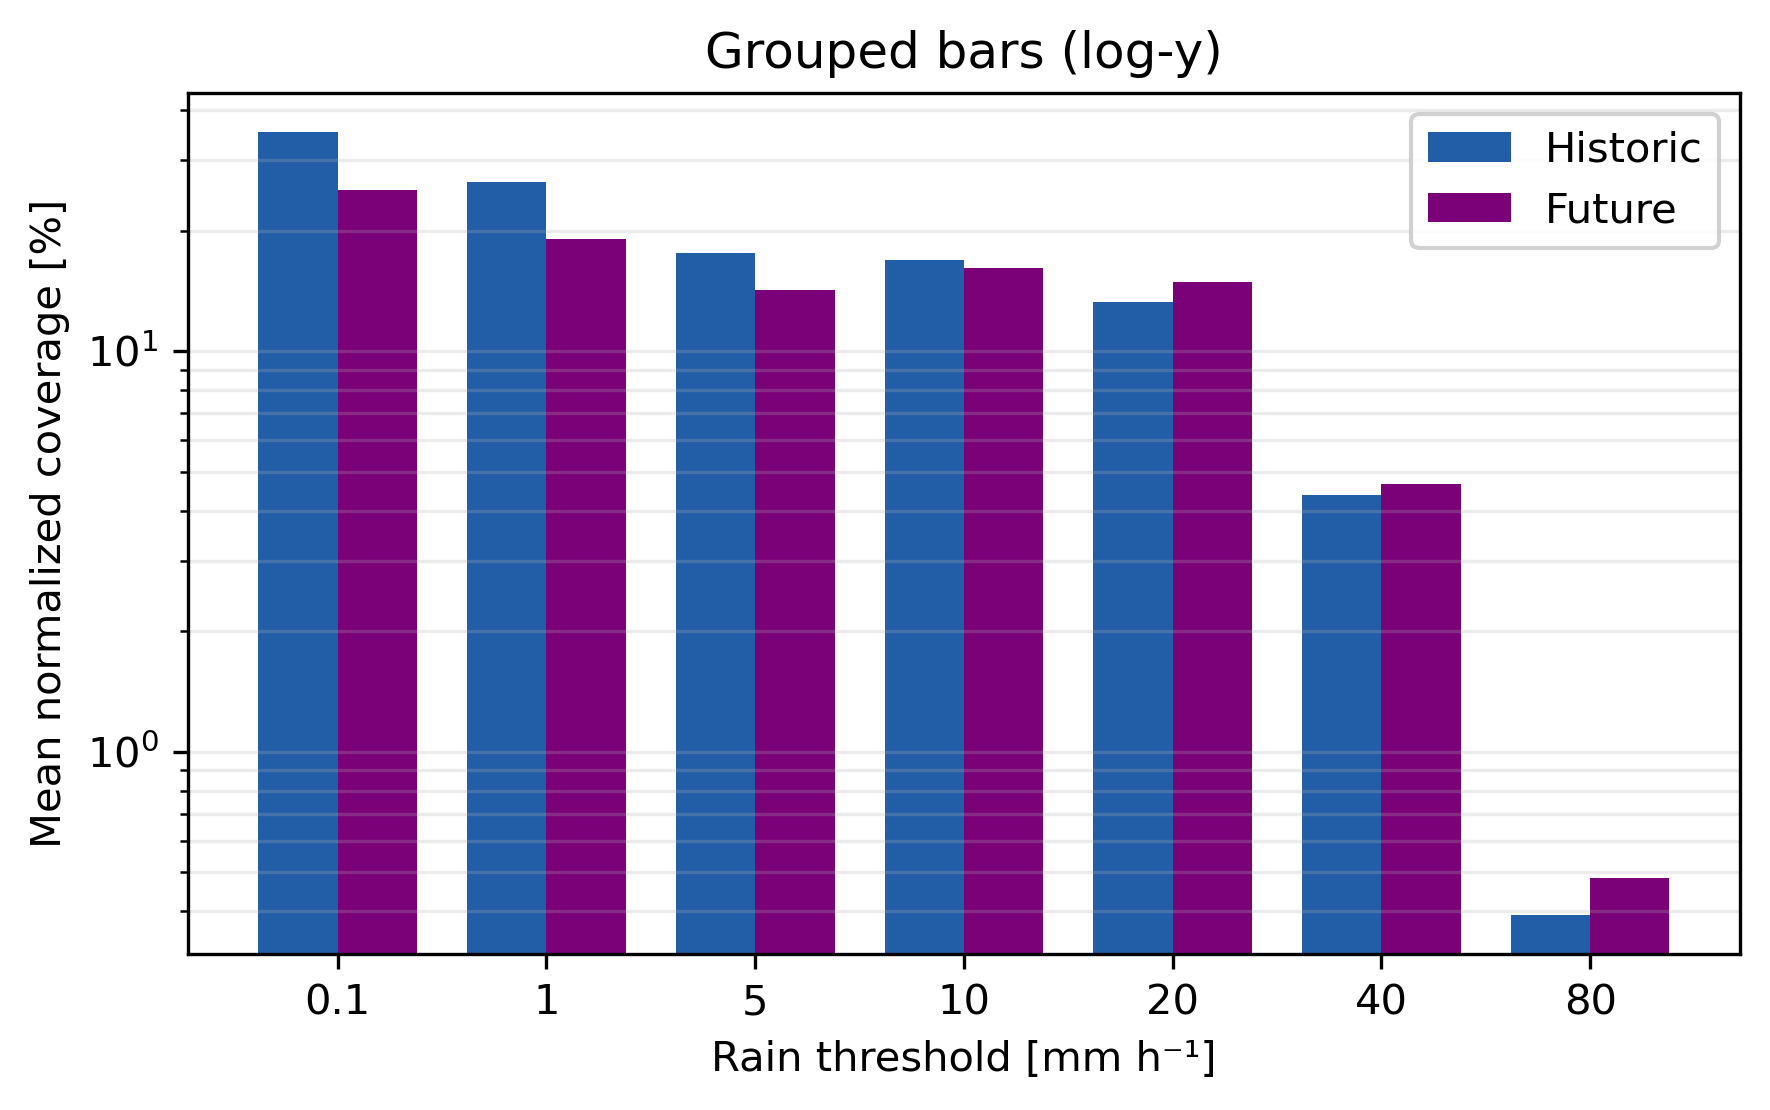

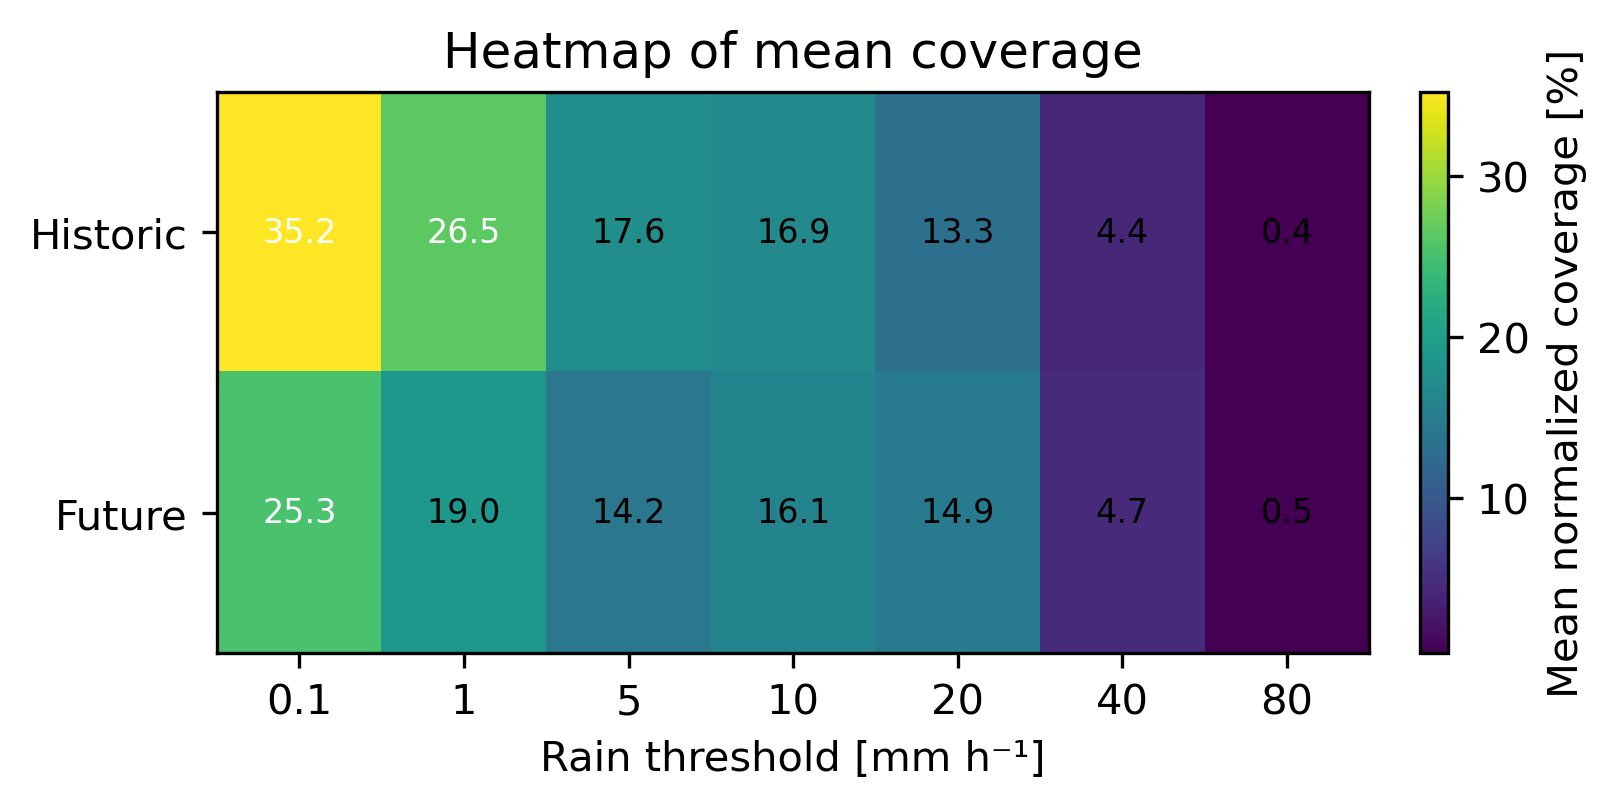

In [13]:
# 1) הקו עם זום לטווח 10–80
fig, (ax, axins) = plot_mean_with_zoom(means, title="Mean coverage with zoom (10–80)")
plt.show()

# 2) חמישה ייצוגים אלטרנטיביים:
plot_delta_vs_threshold(means, title="Δ% (future − historic)")
plot_dumbbell_horizontal(means)
plot_grouped_bars(means, title="Grouped bars (log-y)")
plot_heatmap_2xN(means, title="Heatmap of mean coverage")
plt.show()


C:\Users\raznu\AppData\Local\Temp\ipykernel_37244\4179899846.py:430: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


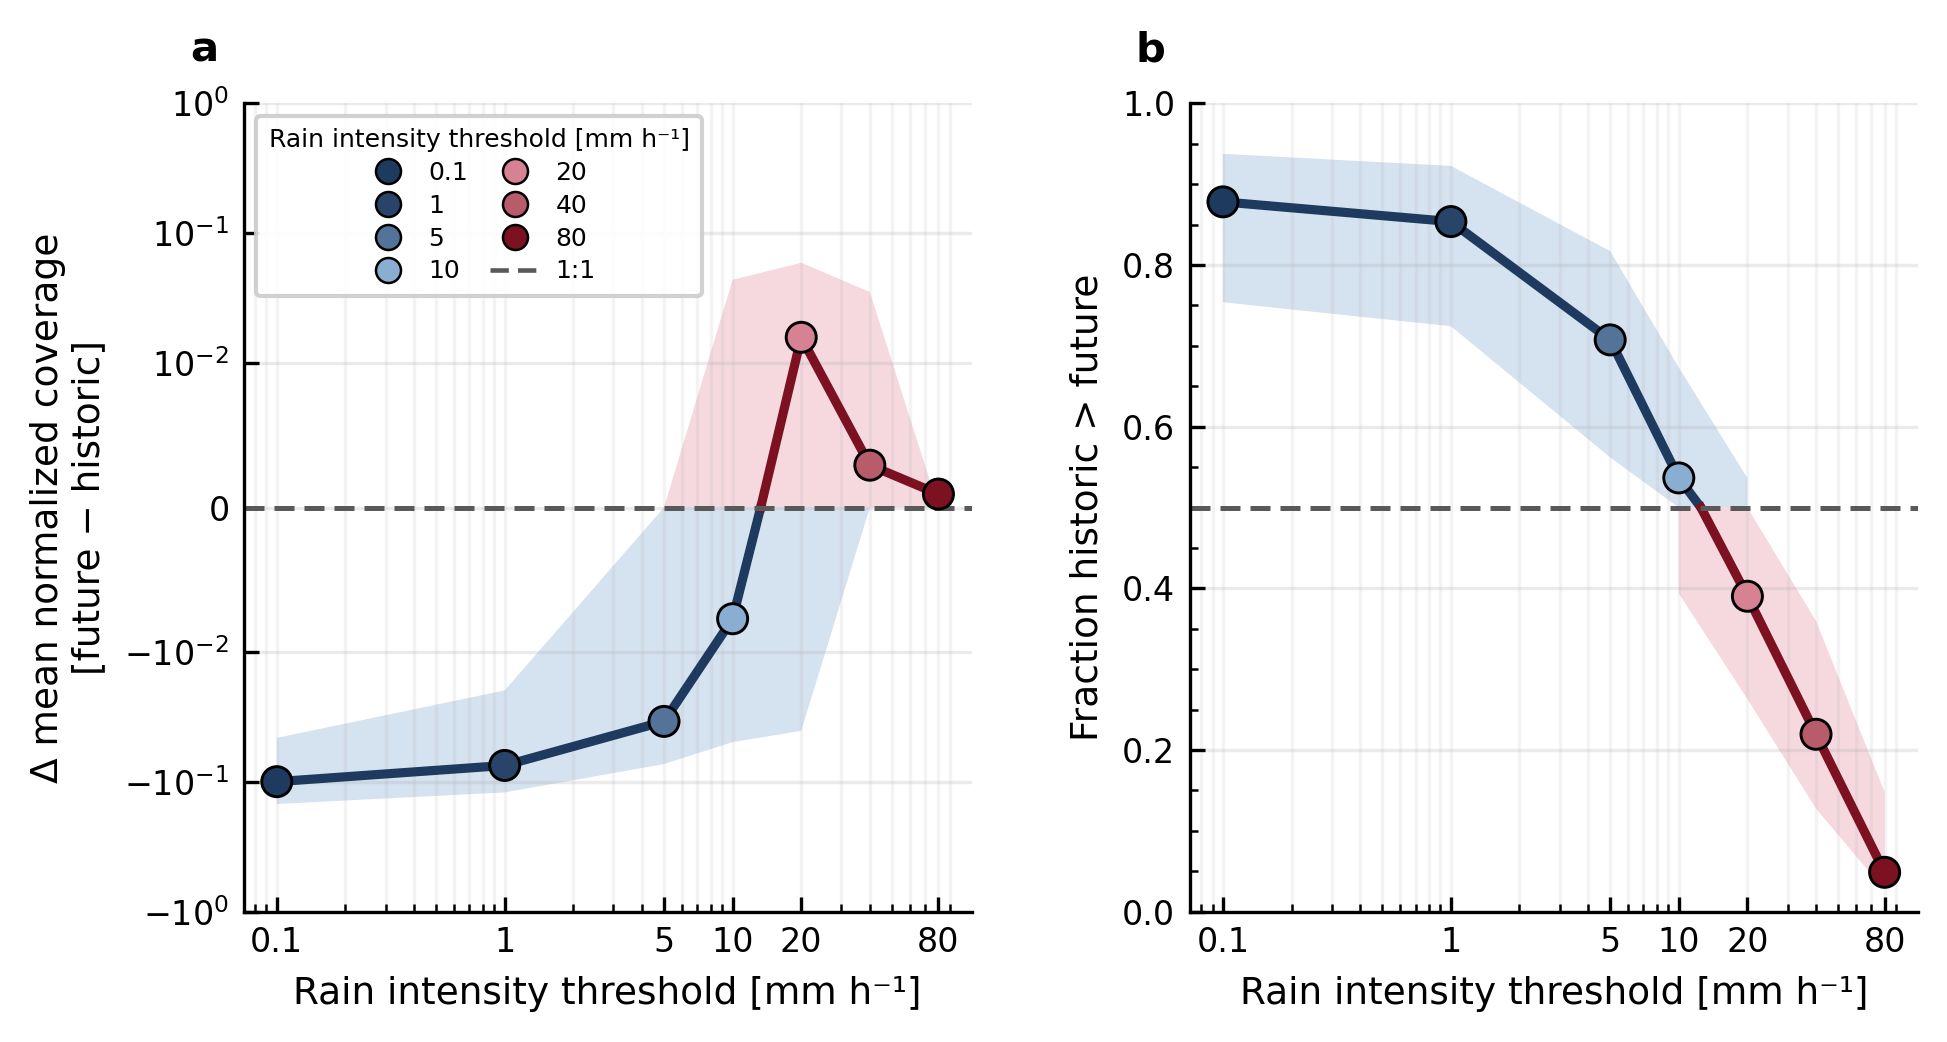

In [14]:
# Figure: two panels with threshold-colored points and a split two-column legend
# Left: Δ mean or median normalized coverage with symmetric symlog y-scale
# Right: Fraction of events with historic > future with Wilson 95% CI

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from contextlib import contextmanager
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

# ---------- compact Nature-like style ----------
@contextmanager
def nature_rc():
    with plt.rc_context({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.labelsize": 9, "axes.titlesize": 10,
        "xtick.labelsize": 8, "ytick.labelsize": 8,
        "axes.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.minor.visible": True, "ytick.minor.visible": True,
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2.0, "ytick.minor.size": 2.0,
        "legend.frameon": False,
        "savefig.dpi": 300, "figure.dpi": 300,
    }):
        yield

def _apply_axis_nature(ax, grid_y=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_y:
        ax.grid(True, axis="y", alpha=0.25)
    else:
        ax.grid(False)

def _wilson_ci(p_hat: float, n: int, z: float = 1.96):
    if n <= 0 or not np.isfinite(p_hat):
        return np.nan, np.nan
    denom = 1 + z**2 / n
    center = (p_hat + z**2/(2*n)) / denom
    half = z*np.sqrt((p_hat*(1-p_hat) + z**2/(4*n**2)) / n) / denom
    return max(0.0, center-half), min(1.0, center+half)

def _compute_per_event_reduce(data_norm: pd.DataFrame, event_reduce: str = "mean") -> pd.DataFrame:
    if event_reduce not in {"mean", "median"}:
        raise ValueError("event_reduce must be mean or median")
    agg = data_norm.groupby(["rain_threshold_mm_per_hr", "event_id"], as_index=False).agg(
        historic_event=("historic_norm", event_reduce),
        future_event  =("future_norm",   event_reduce),
    )
    agg["delta_event"] = agg["future_event"] - agg["historic_event"]
    return agg

def _plot_splitline(ax, x, y, baseline, color_pos, color_neg, **kw):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    for i in range(len(x)-1):
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        if not (np.isfinite(x0) and np.isfinite(x1) and np.isfinite(y0) and np.isfinite(y1)):
            continue
        s0, s1 = y0 - baseline, y1 - baseline
        if s0*s1 > 0:
            ax.plot([x0, x1], [y0, y1],
                    color=(color_pos if s0 > 0 else color_neg), **kw)
        elif s0*s1 < 0:
            t = (baseline - y0) / (y1 - y0) if y1 != y0 else 0.5
            xc = x0 + t*(x1 - x0)
            ax.plot([x0, xc], [y0, baseline],
                    color=(color_pos if s0 > 0 else color_neg), **kw)
            ax.plot([xc, x1], [baseline, y1],
                    color=(color_pos if s1 > 0 else color_neg), **kw)
        else:
            ax.plot([x0, x1], [y0, y1],
                    color=(color_pos if s0 >= 0 else color_neg), **kw)

def _adaptive_threshold_ticks(thr: np.ndarray, use_log: bool, max_labels: int = 6):
    x = np.asarray(thr, float)
    if x.size == 0:
        return np.array([]), []
    xs = np.log10(x) if use_log else x
    span = xs.max() - xs.min()
    if span <= 0 or max_labels < 2:
        ticks = x
    else:
        min_sep = span / (max_labels - 1) * 0.9
        chosen = [0]
        last = xs[0]
        for i in range(1, len(x) - 1):
            if xs[i] - last >= min_sep:
                chosen.append(i)
                last = xs[i]
        if chosen[-1] != len(x) - 1:
            chosen.append(len(x) - 1)
        ticks = x[np.unique(chosen)]
    labels = [f"{t:g}" for t in ticks]
    return ticks, labels

def _set_symlog_symmetric(ax, values, linthresh=0.01, base=10.0, margin=1.05):
    v = np.asarray(values, float)
    vmax = np.nanmax(np.abs(v))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = linthresh
    vmax *= margin
    top = max(linthresh, base ** np.ceil(np.log(vmax) / np.log(base)))
    ax.set_yscale("symlog", linthresh=linthresh, base=base)
    ax.set_ylim(-top, top)

# ---------- threshold based coloring using the blue–rose palette ----------
def _build_threshold_colorer(thresholds_all: np.ndarray,
                             split: float = 10.0):
    """
    Return f(t) -> RGBA for threshold markers.
    t <= split  -> blue side  (historical / safer range)
    t > split   -> rose/crimson side (riskier / higher thresholds)

    Colors aligned with the global palette:
        Blue side:    #1E3A5F -> #89AED2
        Rose side:    #E594A4 -> #7B1121
    """
    thresholds_all = np.asarray(thresholds_all, float)

    # define side colormaps from our fixed palette
    blue_cmap = LinearSegmentedColormap.from_list(
        "thr_blue_side",
        ["#1E3A5F", "#89AED2"]
    )
    rose_cmap = LinearSegmentedColormap.from_list(
        "thr_rose_side",
        ["#E594A4", "#7B1121"]
    )

    # ranges per side
    if np.any(thresholds_all <= split):
        b_min = float(np.nanmin(thresholds_all[thresholds_all <= split]))
        b_max = float(split)
    else:
        b_min = b_max = float(split)

    if np.any(thresholds_all > split):
        p_min = float(split)
        p_max = float(np.nanmax(thresholds_all[thresholds_all > split]))
    else:
        p_min = p_max = float(split)

    def color_for_threshold(t):
        t = float(t)
        if t <= split:
            if b_max == b_min:
                s = 0.5
            else:
                s = (t - b_min) / (b_max - b_min)
            s = np.clip(s, 0.0, 1.0)
            return blue_cmap(s)
        else:
            if p_max == p_min:
                s = 0.5
            else:
                s = (t - p_min) / (p_max - p_min)
            s = np.clip(s, 0.0, 1.0)
            return rose_cmap(s)

    return np.vectorize(color_for_threshold, otypes=[object])

def _all_thresholds_for_legend(all_thr: np.ndarray):
    return np.unique(np.asarray(all_thr, float)).tolist()

def _add_point_legend_split_columns(ax, thresholds_all, thr_color_func,
                                    split: float = 10.0,
                                    title="Rain threshold [mm h\u207B\u00B9]",
                                    marker_edge="black",
                                    include_reference=True,
                                    reference_label="1:1",
                                    reference_linestyle=(0, (4, 2)),
                                    reference_color="0.35",
                                    loc="upper left",
                                    marker_size: float = 6.0,
                                    text_size: float =6.0,
                                    title_size: float = 6.0):
    """
    Legend with two columns:
    left column  = thresholds <= split (blue side),
    right column = thresholds > split (rose/crimson side),
    plus optional 1:1 reference line.
    """
    thr = np.unique(np.asarray(thresholds_all, float))
    left_thr  = sorted([t for t in thr if t <= split])
    right_thr = sorted([t for t in thr if t >  split])

    def handle_point(t):
        return Line2D([0], [0], marker="o", linestyle="",
                      markersize=marker_size,
                      markerfacecolor=thr_color_func(t),
                      markeredgecolor=marker_edge,
                      markeredgewidth=0.6,
                      label=f"{t:g}")

    left_col  = [handle_point(t) for t in left_thr]
    right_col = [handle_point(t) for t in right_thr]

    if include_reference:
        right_col.append(
            Line2D([0], [0],
                   color=reference_color, lw=1.1,
                   ls=reference_linestyle,
                   label=reference_label)
        )

    # pad with invisible spacers to align rows
    nrows = max(len(left_col), len(right_col))
    spacer = Line2D([0], [0], linestyle="", marker="o",
                    markersize=0, alpha=0, label="")
    left_col  += [spacer] * (nrows - len(left_col))
    right_col += [spacer] * (nrows - len(right_col))

    handles = left_col + right_col

    leg = ax.legend(handles=handles,
                    title=title,
                    loc=loc,
                    ncol=2,
                    fontsize=text_size,
                    title_fontsize=title_size,
                    frameon=True,
                    framealpha=0.9,
                    facecolor="white",
                    edgecolor="0.8",
                    borderpad=0.5,
                    labelspacing=0.35,
                    handletextpad=0.6,
                    columnspacing=0.9)
    return leg

# ---------- main figure ----------
def figure_delta_and_fraction_signed_symlogY(
    data_norm: pd.DataFrame,
    means: pd.DataFrame,
    frac_df: pd.DataFrame,
    *,
    event_reduce: str = "mean",
    summary_term: str = "mean",
    spread: str = "iqr",
    auto_log_x: bool = True,
    # colors aligned with global palette
    col_future: str = "#7B1121",
    col_future_band: str = "#E594A4",
    col_hist: str = "#1E3A5F",
    col_hist_band: str = "#89AED2",
    marker_edge: str = "black",
    max_xtick_labels: int = 6,
    symlog_linthresh: float = 0.01,
    symlog_base: float = 10.0,
    thr_split_for_colors: float = 10.0,
    show_point_legend: bool = True,
    legend_loc: str = "upper left",
    x_ref: float = 10.0  # << חדש: נרצה שיופיע ויקבל קו
):
    ms = means.sort_values("rain_threshold_mm_per_hr").copy()
    thr = ms["rain_threshold_mm_per_hr"].astype(float).values
    ms["delta_summary"] = ms["future_center"] - ms["historic_center"]

    pe = _compute_per_event_reduce(data_norm, event_reduce=event_reduce)
    g = pe.groupby("rain_threshold_mm_per_hr")

    if spread == "iqr":
        band = g["delta_event"].quantile([0.25, 0.75]).unstack().rename(
            columns={0.25: "lo", 0.75: "hi"}
        )
    elif spread == "minmax":
        band = g["delta_event"].agg(lo="min", hi="max")
    else:
        raise ValueError("spread must be 'iqr' or 'minmax'")

    a_df = (
        ms[["rain_threshold_mm_per_hr", "delta_summary"]]
        .merge(band, on="rain_threshold_mm_per_hr", how="left")
        .sort_values("rain_threshold_mm_per_hr")
    )

    n_per_thr = (
        data_norm.groupby(["rain_threshold_mm_per_hr", "event_id"])
        .size()
        .reset_index()
        .groupby("rain_threshold_mm_per_hr")
        .size()
        .rename("n_events")
        .reset_index()
    )

    b_df = (
        frac_df.merge(n_per_thr, on="rain_threshold_mm_per_hr", how="left")
        .sort_values("rain_threshold_mm_per_hr")
    )

    lohi = np.array([
        _wilson_ci(p, int(n))
        for p, n in zip(
            b_df["fraction_historic_gt_future"],
            b_df["n_events"].fillna(0),
        )
    ])
    b_df["lo"], b_df["hi"] = lohi[:, 0], lohi[:, 1]

    use_log = False
    if auto_log_x:
        pos = thr[thr > 0]
        use_log = len(pos) >= 2 and (pos.max() / max(pos.min(), 1e-12) >= 20)

    thr_color = _build_threshold_colorer(
        thresholds_all=thr,
        split=thr_split_for_colors
    )

    with nature_rc():
        fig, axs = plt.subplots(
            1, 2, figsize=(7.2, 3.5), dpi=300,
            gridspec_kw={"wspace": 0.3}
        )

        # ---------- (a) Δ normalized coverage ----------
        axL = axs[0]
        if use_log:
            axL.set_xscale("log")

        x = a_df["rain_threshold_mm_per_hr"].to_numpy(float)
        lo = a_df["lo"].to_numpy(float)
        hi = a_df["hi"].to_numpy(float)
        d  = a_df["delta_summary"].to_numpy(float)

        axL.fill_between(
            x, np.clip(lo, 0, None), np.clip(hi, 0, None),
            color=col_future_band, alpha=0.35, edgecolor="none",
        )
        axL.fill_between(
            x, np.clip(lo, None, 0), np.clip(hi, None, 0),
            color=col_hist_band, alpha=0.35, edgecolor="none",
        )

        _plot_splitline(axL, x, d, 0.0, col_future, col_hist, lw=2.2)

        axL.scatter(
            x, d, s=52,
            c=np.array(list(thr_color(x))),
            edgecolors=marker_edge, linewidths=0.7, zorder=3,
        )



        axL.axhline(0.0, color="0.35", lw=1.2, ls=(0, (4, 2)))
        axL.set_xlabel("Rain intensity threshold [mm h\u207B\u00B9]")
        axL.set_ylabel(f"Δ {summary_term} normalized coverage\n[future − historic]")
        _apply_axis_nature(axL, grid_y=True)
        if use_log:
            axL.grid(True, axis="x", which="both", alpha=0.15)

        ticks, _ = _adaptive_threshold_ticks(thr, use_log, max_labels=max_xtick_labels)
        if np.isfinite(x_ref) and (x.min() <= x_ref <= x.max()):
            ticks = np.unique(np.r_[ticks, x_ref])
        axL.set_xticks(ticks)
        axL.set_xticklabels([f"{t:g}" for t in ticks])

        _set_symlog_symmetric(axL, np.r_[lo, hi, d], linthresh=symlog_linthresh, base=symlog_base)

        if show_point_legend:
            _add_point_legend_split_columns(
                axL, thresholds_all=thr, thr_color_func=thr_color,
                split=thr_split_for_colors, title="Rain intensity threshold [mm h\u207B\u00B9]",
                marker_edge=marker_edge, include_reference=True,
                reference_label="1:1", loc=legend_loc,
                marker_size=6.0, text_size=6.0, title_size=6.0,
            )

        axL.annotate("a", xy=(0, 1), xycoords="axes fraction",
                     xytext=(-6, 8), textcoords="offset points",
                     ha="right", va="bottom", fontweight="bold")

        # ---------- (b) Fraction with CI ----------
        axR = axs[1]
        if use_log:
            axR.set_xscale("log")

        x2  = b_df["rain_threshold_mm_per_hr"].to_numpy(float)
        y   = b_df["fraction_historic_gt_future"].to_numpy(float)
        lo2 = b_df["lo"].to_numpy(float)
        hi2 = b_df["hi"].to_numpy(float)
        base = 0.5

        axR.fill_between(
            x2,
            np.where(hi2 > base, np.maximum(lo2, base), np.nan),
            np.where(hi2 > base, hi2, np.nan),
            color=col_hist_band, alpha=0.35, edgecolor="none",
        )
        axR.fill_between(
            x2,
            np.where(lo2 < base, lo2, np.nan),
            np.where(lo2 < base, np.minimum(hi2, base), np.nan),
            color=col_future_band, alpha=0.35, edgecolor="none",
        )

        _plot_splitline(axR, x2, y, base, col_hist, col_future, lw=2.2)

        axR.scatter(
            x2, y, s=52,
            c=np.array(list(thr_color(x2))),
            edgecolors=marker_edge, linewidths=0.7, zorder=3,
        )

        axR.axhline(base, color="0.35", lw=1.2, ls=(0, (4, 2)))
        axR.set_ylim(0, 1.0)
        axR.set_xlabel("Rain intensity threshold [mm h\u207B\u00B9]")
        axR.set_ylabel("Fraction historic > future")
        _apply_axis_nature(axR, grid_y=True)
        if use_log:
            axR.grid(True, axis="x", which="both", alpha=0.15)

        ticks2, _ = _adaptive_threshold_ticks(thr, use_log, max_labels=max_xtick_labels)
        if np.isfinite(x_ref) and (x2.min() <= x_ref <= x2.max()):
            ticks2 = np.unique(np.r_[ticks2, x_ref])
        axR.set_xticks(ticks2)
        axR.set_xticklabels([f"{t:g}" for t in ticks2])

        axR.annotate("b", xy=(0, 1), xycoords="axes fraction",
                     xytext=(-6, 8), textcoords="offset points",
                     ha="right", va="bottom", fontweight="bold")

        plt.tight_layout()
        return fig, axs


# Example (comment out in production)
fig, axs = figure_delta_and_fraction_signed_symlogY(
    data_norm, means, frac_df,
    event_reduce="mean", summary_term="mean",
    spread="iqr",
    show_point_legend=True, legend_loc="upper left",
    thr_split_for_colors=10.0
)
plt.show()


C:\Users\raznu\AppData\Local\Temp\ipykernel_37244\1275017985.py:329: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


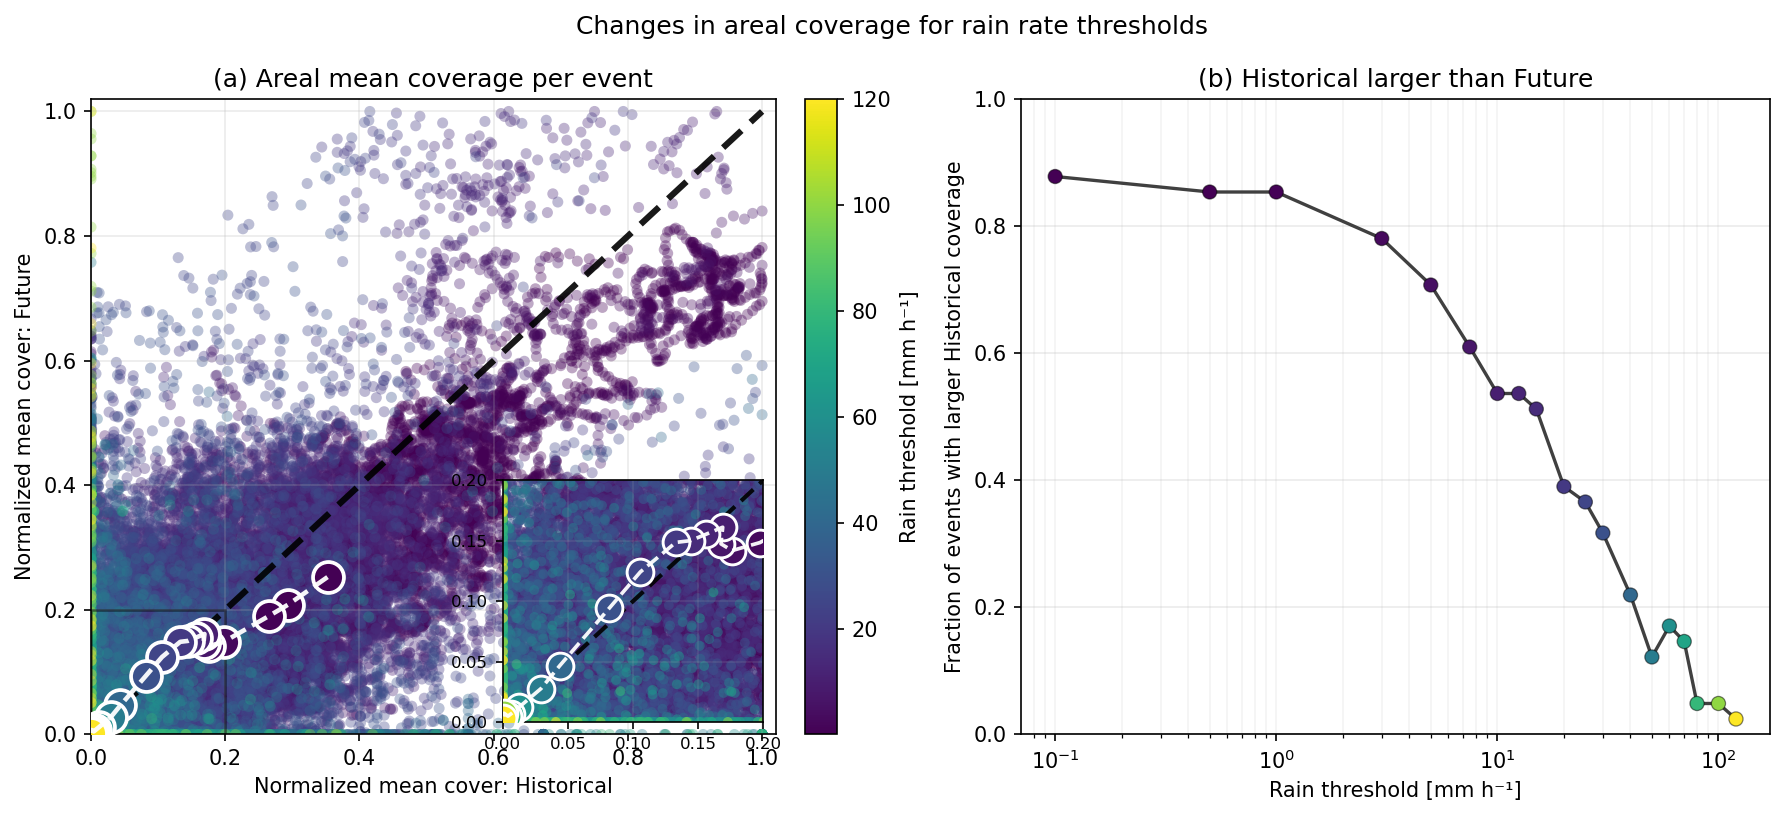

In [15]:
# Basic example
# 1 Build the paired table historic vs future
pairs = build_event_level_pairs(
    wet_by_threshold,
    wet_metric="mean",
#     threshold_filter=[0.1, 1, 10,15, 25, 50, 80],  # you may also pass strings like "0_1"
#     urbanization_filter=["38%", "53%"]            # limit to specific urbanization levels
)

# 2 Normalize and summarize
data_norm, means, frac_df = normalize_and_summarize(
    pairs,
    center="mean",      # "mean" or "median" for the big circles
    event_reduce="mean"   # "mean" or "median" for per event reduction in panel b
)

# 3 Plot
fig, axs = plot_areal_coverage_changes(
    data_norm, means, frac_df,
    title="Changes in areal coverage for rain rate thresholds",
    show_inset=True,
    inset_xlim=(0.0, 0.2),
    inset_ylim=(0.0, 0.2),
    use_log_x=None  # None auto choose, True force log, False force linear
)
plt.show()


In [16]:


def _threshold_palette(thresholds: np.ndarray, cmap_name: str = "viridis"):
    """Return a Normalize and a color function color_for(thr)."""
    thresholds = np.asarray(thresholds, float)
    vmin, vmax = float(np.nanmin(thresholds)), float(np.nanmax(thresholds))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = 0.0, 1.0
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.get_cmap(cmap_name)
    return norm, cmap, (lambda t: cmap(norm(float(t))))

def _compute_per_event_reduce(data_norm: pd.DataFrame, event_reduce: str = "mean") -> pd.DataFrame:
    """Per threshold and event: reduce historic_norm and future_norm to a single value."""
    if event_reduce not in {"mean", "median"}:
        raise ValueError("event_reduce must be mean or median")
    agg = data_norm.groupby(["rain_threshold_mm_per_hr", "event_id"], as_index=False).agg(
        historic_event=("historic_norm", event_reduce),
        future_event=("future_norm", event_reduce),
    )
    agg["delta_event"] = agg["future_event"] - agg["historic_event"]
    agg["avg_event"] = 0.5 * (agg["future_event"] + agg["historic_event"])
    return agg

def _wilson_ci(p_hat: float, n: int, z: float = 1.96) -> Tuple[float, float]:
    """Wilson score interval for a proportion."""
    if n <= 0:
        return np.nan, np.nan
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2*n)) / denom
    half = z * np.sqrt((p_hat*(1-p_hat) + z**2/(4*n)) / n) / denom
    return max(0.0, center - half), min(1.0, center + half)

# ================================================================
# 1) Means path only — clean centers with labels, no background points
# ================================================================
def plot_means_path_only(
    means: pd.DataFrame,
    title: str = "Normalized areal coverage centers",
    annotate_thresholds: bool = True,
    cmap_name: str = "viridis",
    circle_size: int = 240,
    edgecolor: str = "white",
    edgewidth: float = 2.0,
    path_color: str = "black",
    path_lw: float = 2.2,
    path_ls: str = "--"
):
    """
    Show only the per-threshold centers and a path connecting them.
    Uses columns: rain_threshold_mm_per_hr, historic_center, future_center
    """
    thr = np.asarray(means["rain_threshold_mm_per_hr"].values, float)
    norm, cmap, color_for = _threshold_palette(thr, cmap_name)
    ms = means.sort_values("rain_threshold_mm_per_hr")

    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    ax.plot(ms["historic_center"], ms["future_center"], color=path_color, lw=path_lw, ls=path_ls, zorder=1)

    for _, row in ms.iterrows():
        t = float(row["rain_threshold_mm_per_hr"])
        ax.scatter(row["historic_center"], row["future_center"],
                   s=circle_size, facecolors=color_for(t),
                   edgecolors=edgecolor, linewidths=edgewidth, zorder=2)
        if annotate_thresholds:
            ax.text(row["historic_center"], row["future_center"], f"{t:g}",
                    ha="center", va="center", fontsize=8, color="black", zorder=3)

    # identity line
    ax.plot([0, 1], [0, 1], color="0.2", lw=2.0, linestyle=(0, (4, 2)), alpha=0.9)

    ax.set_aspect("equal", "box")
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
    ax.set_xlabel("Normalized historic")
    ax.set_ylabel("Normalized future")
    ax.set_title(title)

    # colorbar
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Rain threshold [mm h\u207B\u00B9]")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    return fig, ax

# ======================================================================
# 2) Delta of centers vs threshold with spread across events (IQR or minmax)
# ======================================================================
def plot_delta_centers_with_spread(
    data_norm: pd.DataFrame,
    means: pd.DataFrame,
    event_reduce: str = "mean",
    spread: str = "iqr",   # "iqr" or "minmax"
    title: str = "Future minus historic center vs threshold",
    cmap_name: str = "viridis",
    use_log_x: Optional[bool] = None
):
    """
    y1: Δcenter = future_center - historic_center
    Band: spread of per-event Δ (IQR or min-max) for context.
    """
    assert spread in {"iqr", "minmax"}
    thr = np.sort(means["rain_threshold_mm_per_hr"].astype(float).values)
    norm, cmap, color_for = _threshold_palette(thr, cmap_name)

    # center delta from means
    center_delta = means.sort_values("rain_threshold_mm_per_hr").assign(
        delta_center=lambda d: d["future_center"] - d["historic_center"]
    )[["rain_threshold_mm_per_hr", "delta_center"]]

    # per-event deltas
    pe = _compute_per_event_reduce(data_norm, event_reduce=event_reduce)
    g = pe.groupby("rain_threshold_mm_per_hr")

    if spread == "iqr":
        band = g["delta_event"].quantile([0.25, 0.75]).unstack()
        band.columns = ["lo", "hi"]
    else:
        band = g["delta_event"].agg(lo="min", hi="max")

    # counts for transparency scaling if desired
    counts = g.size().rename("n").to_frame()

    df = center_delta.merge(band, on="rain_threshold_mm_per_hr", how="left").merge(counts, on="rain_threshold_mm_per_hr", how="left")
    df = df.sort_values("rain_threshold_mm_per_hr")

    fig, ax = plt.subplots(figsize=(7.2, 4.6), dpi=150)

    if use_log_x is None:
        pos = thr[thr > 0]
        auto_log = len(pos) >= 2 and (pos.max() / max(pos.min(), 1e-12) >= 20)
    else:
        auto_log = bool(use_log_x)
    if auto_log:
        ax.set_xscale("log")

    # band
    ax.fill_between(df["rain_threshold_mm_per_hr"], df["lo"], df["hi"],
                    alpha=0.18, color="0.3", edgecolor="none", label="Event spread")

    # line and markers
    ax.plot(df["rain_threshold_mm_per_hr"], df["delta_center"], lw=2.0, color="0.1")
    ax.scatter(df["rain_threshold_mm_per_hr"], df["delta_center"],
               s=60, c=[color_for(t) for t in df["rain_threshold_mm_per_hr"]], edgecolors="black", linewidths=0.5)

    ax.axhline(0.0, color="0.25", lw=1.5, ls=(0, (4, 2)))
    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("Δ center (future − historic)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    if auto_log:
        ax.grid(True, axis="x", which="both", alpha=0.15)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.get_cmap(cmap_name)); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Rain threshold [mm h\u207B\u00B9]")

    plt.tight_layout()
    return fig, ax

# ==========================================================================
# 3) Fraction historic > future with Wilson 95% CI per threshold
# ==========================================================================
def plot_fraction_historic_ci(
    data_norm: pd.DataFrame,
    frac_df: pd.DataFrame,
    title: str = "Historic larger than future — fraction with 95% CI",
    cmap_name: str = "viridis",
    use_log_x: Optional[bool] = None
):
    """
    Uses frac_df plus Wilson CI based on number of events per threshold.
    """
    # count events per threshold
    ev = data_norm.groupby(["rain_threshold_mm_per_hr", "event_id"]).size().rename("nrow").reset_index()
    n_per_thr = ev.groupby("rain_threshold_mm_per_hr").size().rename("n_events").reset_index()

    df = frac_df.merge(n_per_thr, on="rain_threshold_mm_per_hr", how="left").copy()
    df["lo"], df["hi"] = zip(*[ _wilson_ci(p, int(n)) if pd.notnull(p) and pd.notnull(n) else (np.nan, np.nan)
                                for p, n in zip(df["fraction_historic_gt_future"], df["n_events"]) ])
    df = df.sort_values("rain_threshold_mm_per_hr")
    thr = df["rain_threshold_mm_per_hr"].astype(float).values
    norm, cmap, color_for = _threshold_palette(thr, cmap_name)

    fig, ax = plt.subplots(figsize=(7.2, 4.6), dpi=150)

    if use_log_x is None:
        pos = thr[thr > 0]
        auto_log = len(pos) >= 2 and (pos.max() / max(pos.min(), 1e-12) >= 20)
    else:
        auto_log = bool(use_log_x)
    if auto_log:
        ax.set_xscale("log")

    ax.fill_between(df["rain_threshold_mm_per_hr"], df["lo"], df["hi"], color="0.5", alpha=0.2, label="95% CI")
    ax.plot(df["rain_threshold_mm_per_hr"], df["fraction_historic_gt_future"], color="0.15", lw=2.0)
    ax.scatter(df["rain_threshold_mm_per_hr"], df["fraction_historic_gt_future"],
               s=60, c=[color_for(t) for t in thr], edgecolors="black", linewidths=0.5)

    ax.axhline(0.5, color="0.3", lw=1.5, ls=(0, (4, 2)))
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("Fraction historic > future")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    if auto_log:
        ax.grid(True, axis="x", which="both", alpha=0.15)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.get_cmap(cmap_name)); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Rain threshold [mm h\u207B\u00B9]")

    plt.tight_layout()
    return fig, ax

# ================================================================
# 4) Ratio of centers vs threshold (future / historic)
# ================================================================
def plot_center_ratio_vs_threshold(
    means: pd.DataFrame,
    title: str = "Ratio of centers (future over historic) vs threshold",
    cmap_name: str = "viridis",
    log_y: bool = False,
    one_line: float = 1.0
):
    """
    Uses only the centers to plot a compact multiplicative view.
    """
    df = means.sort_values("rain_threshold_mm_per_hr").copy()
    df["ratio"] = df["future_center"] / df["historic_center"]
    thr = df["rain_threshold_mm_per_hr"].astype(float).values
    norm, cmap, color_for = _threshold_palette(thr, cmap_name)

    fig, ax = plt.subplots(figsize=(7.2, 4.6), dpi=150)
    ax.plot(df["rain_threshold_mm_per_hr"], df["ratio"], color="0.15", lw=2.0)
    ax.scatter(df["rain_threshold_mm_per_hr"], df["ratio"],
               s=60, c=[color_for(t) for t in thr], edgecolors="black", linewidths=0.5)

    ax.axhline(one_line, color="0.3", lw=1.5, ls=(0, (4, 2)))

    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("Future / Historic")
    ax.set_title(title)
    if log_y:
        ax.set_yscale("log")
    ax.grid(True, alpha=0.25)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.get_cmap(cmap_name)); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Rain threshold [mm h\u207B\u00B9]")

    plt.tight_layout()
    return fig, ax

# =============================================================================
# 5) Boxplots of per-event Δ (future − historic) per threshold — distribution view
# =============================================================================
def plot_delta_boxplots_by_threshold(
    data_norm: pd.DataFrame,
    event_reduce: str = "mean",
    title: str = "Per event Δ (future − historic) by threshold",
    cmap_name: str = "viridis",
    show_zero_line: bool = True
):
    """
    One Δ value per event and threshold (after per-event reduction), then boxplot by threshold.
    Clean distribution summary without scatter.
    """
    pe = _compute_per_event_reduce(data_norm, event_reduce=event_reduce)
    df = pe[["rain_threshold_mm_per_hr", "delta_event"]].copy()
    order = np.sort(df["rain_threshold_mm_per_hr"].astype(float).unique())
    # Prepare colors per box
    norm, cmap, color_for = _threshold_palette(order, cmap_name)

    data_for_box = [df.loc[df["rain_threshold_mm_per_hr"].astype(float) == t, "delta_event"].dropna().values for t in order]

    fig, ax = plt.subplots(figsize=(8.2, 4.8), dpi=150)
    bp = ax.boxplot(
        data_for_box, positions=range(1, len(order)+1), widths=0.65,
        patch_artist=True, showfliers=False, medianprops=dict(lw=1.8, color="black")
    )

    # Color each box by threshold
    for i, patch in enumerate(bp["boxes"], start=0):
        patch.set_facecolor(color_for(order[i]))
        patch.set_edgecolor("black")
        patch.set_alpha(0.7)

    # x tick labels as thresholds
    ax.set_xticks(range(1, len(order)+1))
    ax.set_xticklabels([f"{t:g}" for t in order], rotation=0)

    if show_zero_line:
        ax.axhline(0.0, color="0.25", lw=1.4, ls=(0, (4, 2)))

    ax.set_xlabel("Rain threshold [mm h\u207B\u00B9]")
    ax.set_ylabel("Δ per event (future − historic)")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.25)

    # add colorbar for reference
    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.get_cmap(cmap_name)); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Rain threshold [mm h\u207B\u00B9]")

    plt.tight_layout()
    return fig, ax


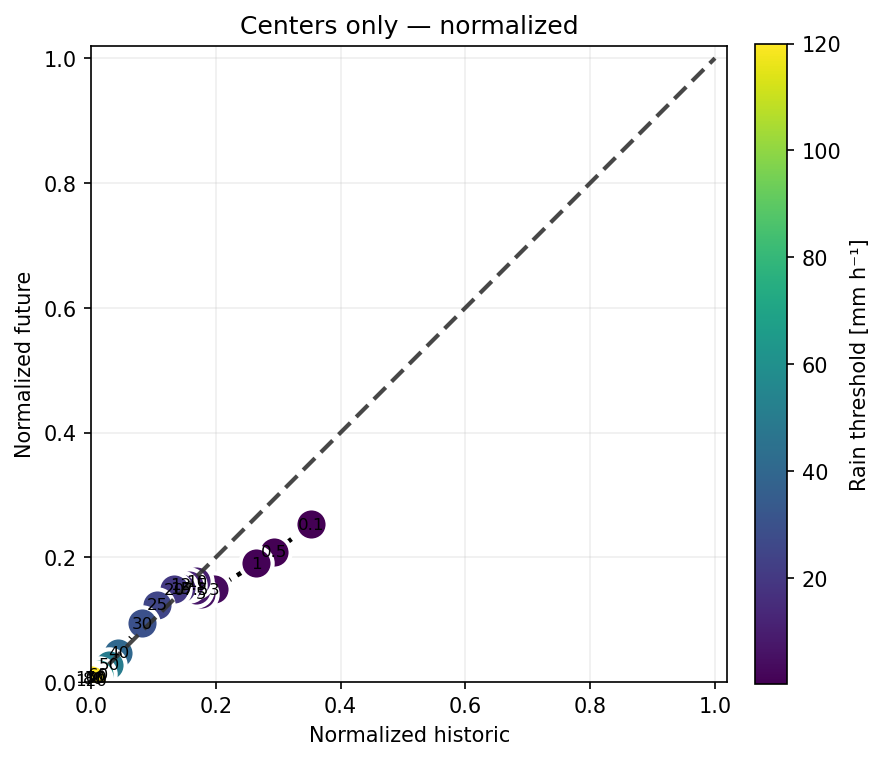

In [17]:
# 1
fig1, ax1 = plot_means_path_only(means, title="Centers only — normalized")

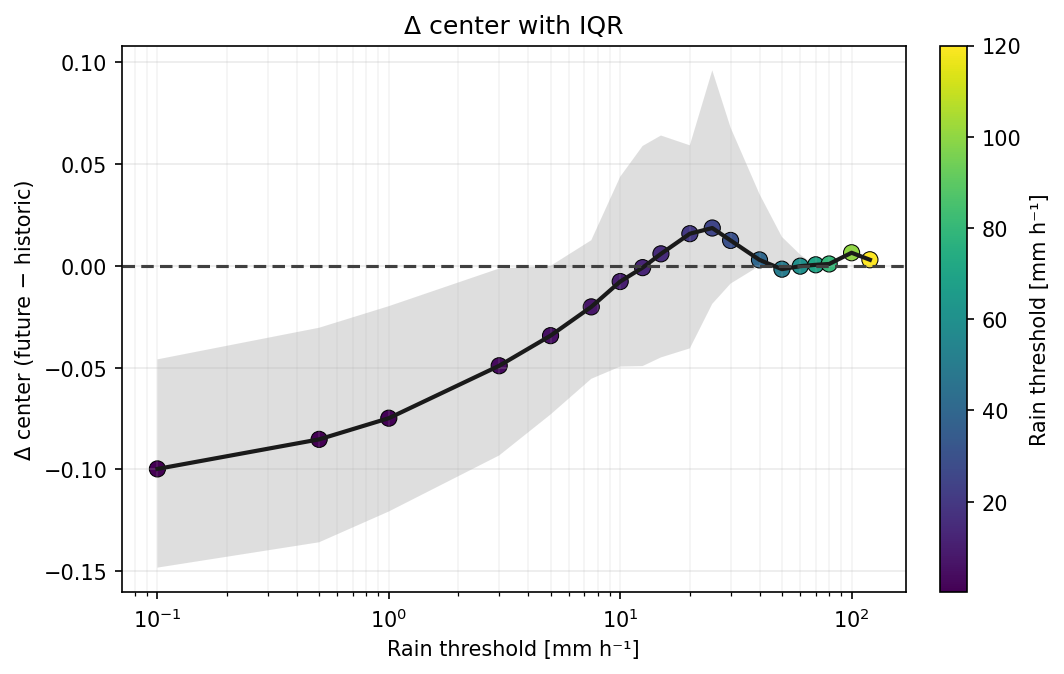

In [18]:
# 2
fig2, ax2 = plot_delta_centers_with_spread(data_norm, means, event_reduce="mean", spread="iqr",
                                           title="Δ center with IQR")

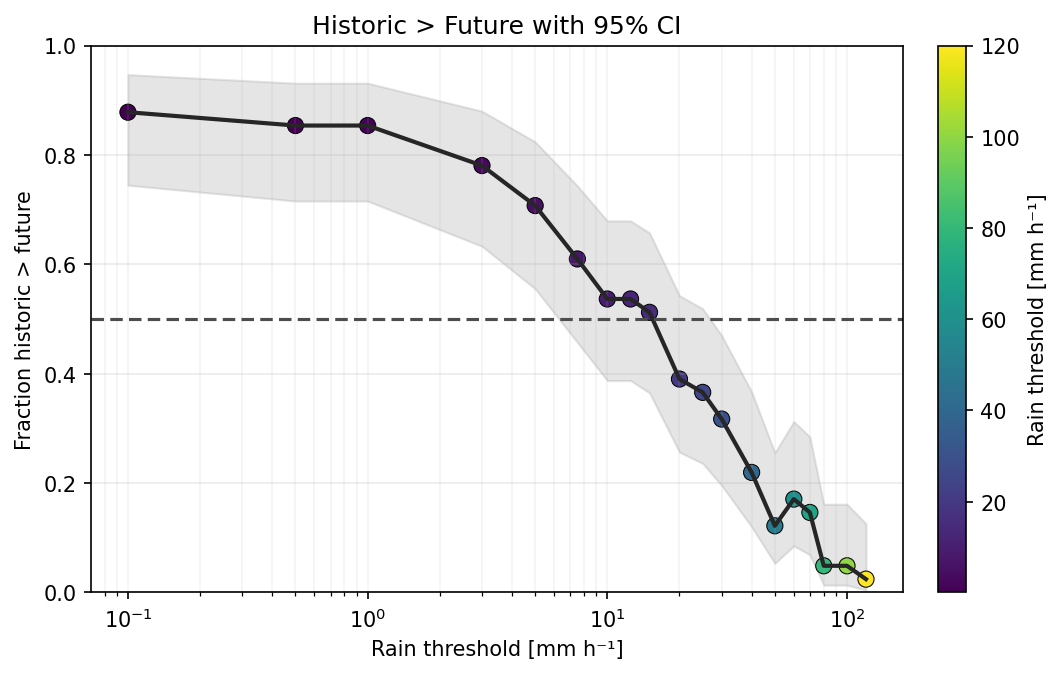

In [19]:
# 3
fig3, ax3 = plot_fraction_historic_ci(data_norm, frac_df, title="Historic > Future with 95% CI")

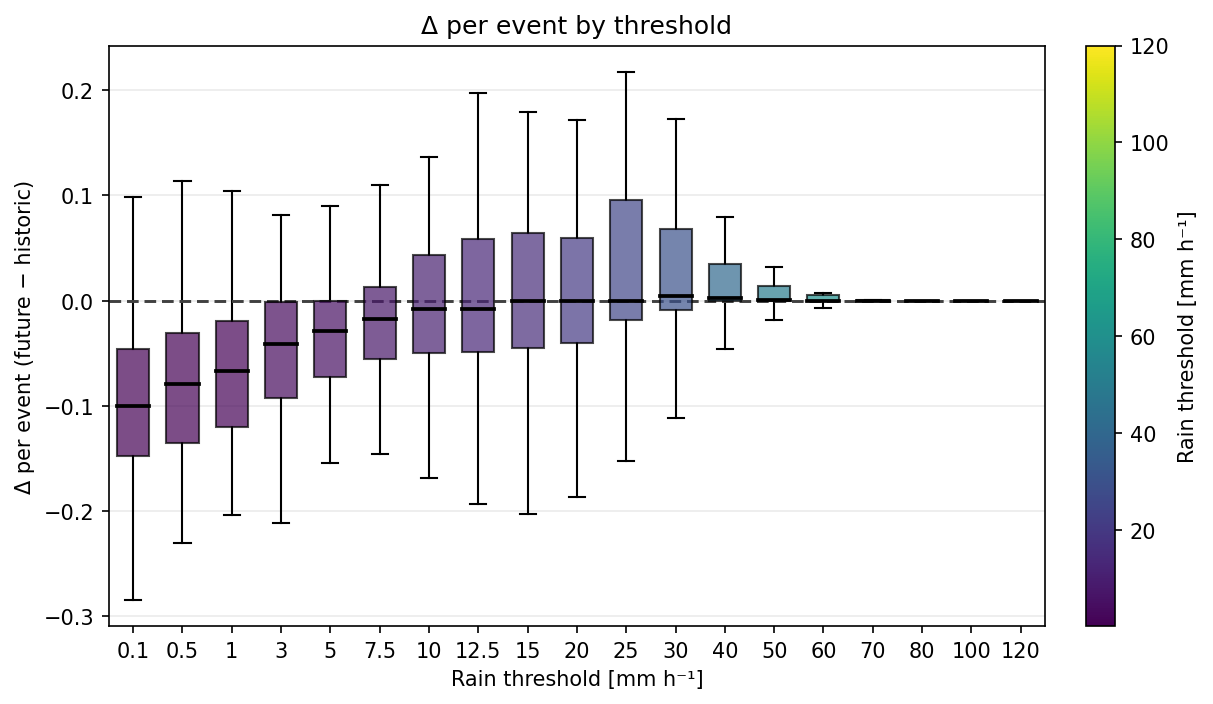

In [20]:
# 5
fig5, ax5 = plot_delta_boxplots_by_threshold(data_norm, event_reduce="mean",
                                             title="Δ per event by threshold")

In [ ]:
data_norm.columns

In [ ]:
//////--------------------------------------------------------------------------------//////////////////////

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Optional

sns.set_theme(style="white", color_codes=True)

def jointgrid_by_threshold(
    df: pd.DataFrame,
    threshold: float,
    event_reduce: str = "mean",    # "mean" or "median"
    size_by: str = "count",        # "count" or "none"
    size_range=(30, 120),
    color=None,
    alpha: float = 0.6,
    marginals: str = "rug",        # "rug" or "hist"
    space: float = 0,
    ratio: float = 17,
    title: Optional[str] = None,
):
    """
    Build a JointGrid for a single rain threshold.
    Each point is one event aggregated across rows that match the threshold.

    X is historic_norm
    Y is future_cover
    """
    required = {"rain_threshold_mm_per_hr","event_id","historic_norm","future_norm"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Robust float filtering
    mask = np.isclose(df["rain_threshold_mm_per_hr"].to_numpy(), threshold, rtol=0, atol=1e-9)
    d = df.loc[mask].copy()
    if d.empty:
        raise ValueError(f"No rows found for threshold {threshold}")

    # Reducer
    reducer = {"mean": "mean", "median": "median"}.get(event_reduce)
    if reducer is None:
        raise ValueError("event_reduce must be 'mean' or 'median'")

    # One row per event
    grp = d.groupby("event_id", as_index=False).agg(
        historic_norm=("historic_norm", reducer),
        future_cover =("future_norm",  reducer),
        n=("event_id", "size")
    ).dropna(subset=["historic_norm","future_norm"])

    # JointGrid
    g = sns.JointGrid(data=grp, x="historic_norm", y="future_norm", space=space, ratio=ratio)

    joint_kwargs = dict(alpha=alpha, color=color, legend=False)

    if size_by == "count":
        g.plot_joint(
            sns.scatterplot,
            data=grp,           # <-- important so size="n" is found
            size="n",
            sizes=size_range,
            **joint_kwargs
        )
    else:
        g.plot_joint(sns.scatterplot, data=grp, s=size_range[0], **joint_kwargs)

    if marginals == "rug":
        g.plot_marginals(sns.rugplot, data=grp, height=1, color=color, alpha=alpha)
    elif marginals == "hist":
        g.plot_marginals(sns.histplot, data=grp, element="step", fill=False, color=color, alpha=0.9)
    else:
        raise ValueError("marginals must be 'rug' or 'hist'")

    g.set_axis_labels("historic_norm", "future_norm")
    g.ax_joint.grid(True, which="both", ls=":", lw=0.6, alpha=0.6)

    if title is None:
        title = f"Threshold = {threshold} mm hr⁻¹  |  per event {event_reduce}"
    g.ax_joint.set_title(title, pad=12)

    return g.fig, g

# Example
fig, g = jointgrid_by_threshold(
    data_norm,
    threshold=10.0,
    event_reduce="mean",
    size_by="count",
    size_range=(30, 140),
    color="g",
    alpha=0.6,
    marginals="rug",
    space=0,
    ratio=17,
)
plt.show()


#  WORKING WITHOUT KOKOS 

#  Data analysis and visualization

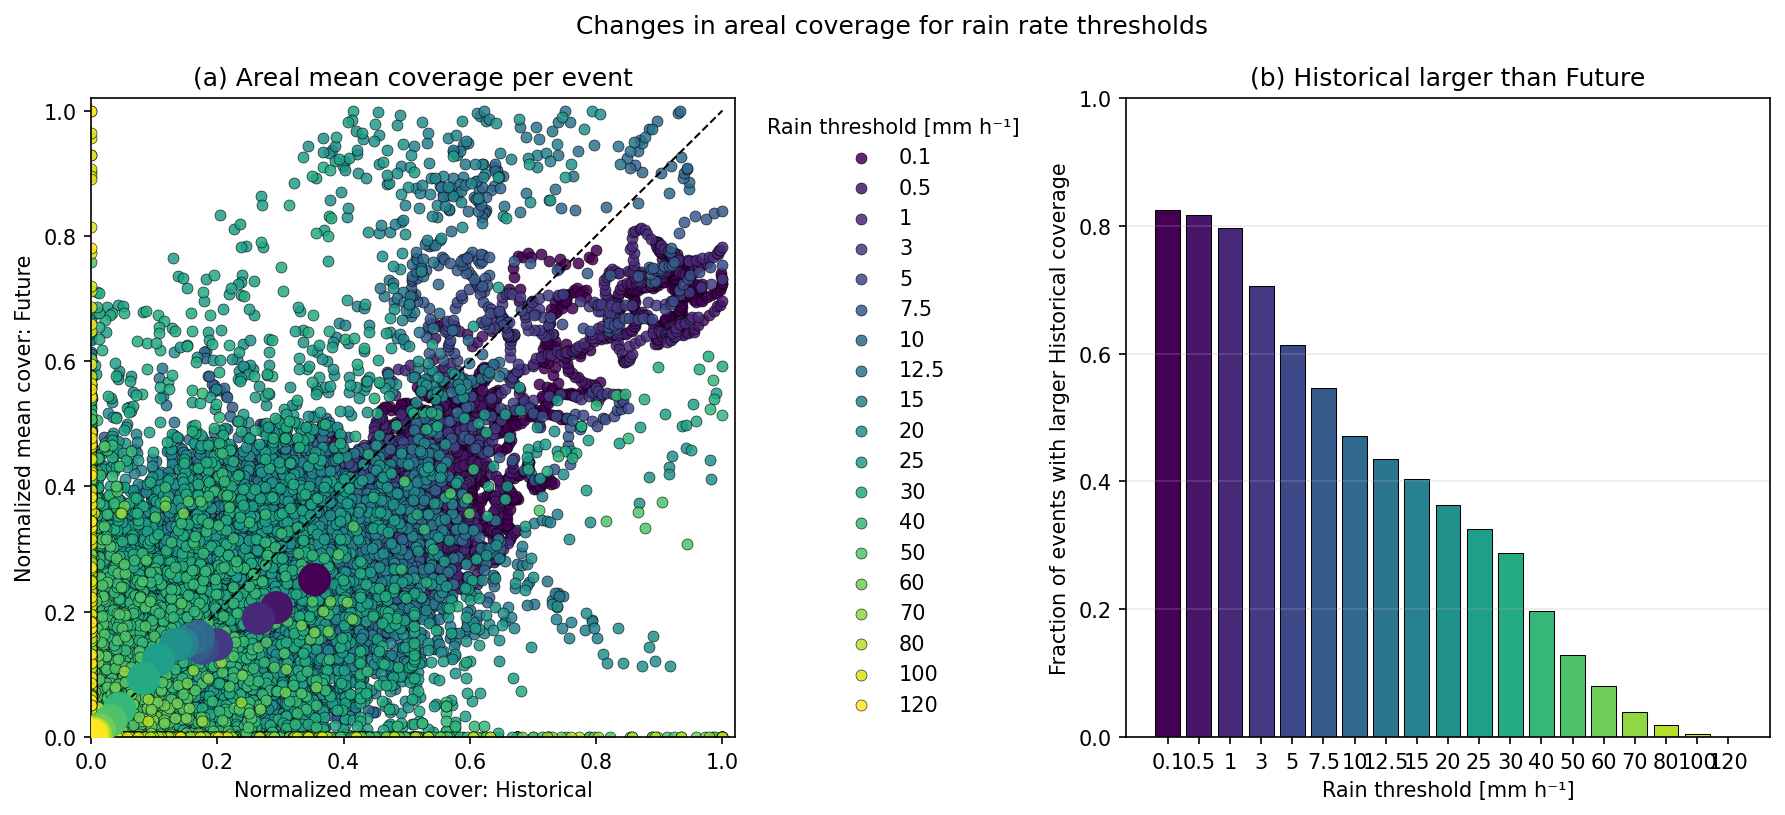

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: use SciPy for paired tests when available
try:
    from scipy.stats import wilcoxon, ttest_rel
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False


def build_event_level_pairs(
    wet_by_threshold: dict[str, pd.DataFrame],
    wet_metric: str = "mean",          # "mean" or "max"
    urbanization_filter: Optional[list[str]] = None,
    use_percent: bool = True,
    deduplicate_across_urbanization: bool = True
) -> pd.DataFrame:
    """
    One point = one original row (event/shift combo). 
    x = historical wet metric, y = future wet metric.
    Optionally deduplicate rows that are identical except for urbanization
    (since wet coverage does not depend on urbanization).

    Returns columns:
      ["threshold_mm_hr","urbanization","event_num","y_shift","d_shift","x","y"]
    """
    assert wet_metric in ("mean", "max"), "wet_metric must be 'mean' or 'max'"

    hist_col = ("historical", "spatial_rain", f"wet_area_percent_{wet_metric}")
    fut_col  = ("future",     "spatial_rain", f"wet_area_percent_{wet_metric}")

    rows = []
    for thr_key, df_thr in wet_by_threshold.items():
        if hist_col not in df_thr.columns or fut_col not in df_thr.columns:
            continue

        df = df_thr.copy()

        wanted_cols = [
            ("event_num", "", ""), ("y", "", ""), ("d", "", ""),
            ("urbanization", "", ""), hist_col, fut_col
        ]
        wanted_cols = [c for c in wanted_cols if c in df.columns]
        df = df.loc[:, wanted_cols].copy()

        # flatten MI columns
        df.columns = [
            c[0] if isinstance(c, tuple) and len(c) == 3 and c[1] == c[2] == "" else
            "|".join(c) if isinstance(c, tuple) else c
            for c in df.columns
        ]

        # rename shift columns to avoid name clash with plotting y
        if "y" in df.columns:
            df.rename(columns={"y": "y_shift"}, inplace=True)
        if "d" in df.columns:
            df.rename(columns={"d": "d_shift"}, inplace=True)

        if urbanization_filter is not None and "urbanization" in df.columns:
            df = df[df["urbanization"].isin(urbanization_filter)]

        df["x"] = pd.to_numeric(df[f"historical|spatial_rain|wet_area_percent_{wet_metric}"], errors="coerce")
        df["y"] = pd.to_numeric(df[f"future|spatial_rain|wet_area_percent_{wet_metric}"], errors="coerce")
        df = df.dropna(subset=["x", "y"])

        if use_percent and max(df["x"].max(), df["y"].max()) <= 1.0 + 1e-9:
            df["x"] = df["x"] * 100.0
            df["y"] = df["y"] * 100.0

        df["threshold_mm_hr"] = float(str(thr_key).replace("_", "."))
        if "event_num" in df.columns:
            df["event_num"] = df["event_num"].astype(str)

        # optional deduplication to remove duplicates across urbanization
        if deduplicate_across_urbanization:
            subset_cols = [c for c in ["threshold_mm_hr","event_num","y_shift","d_shift","x","y"] if c in df.columns]
            df = df.sort_values(subset_cols)
            df = df.drop_duplicates(subset=subset_cols, keep="first")

        keep_cols = [c for c in ["threshold_mm_hr","urbanization","event_num","y_shift","d_shift","x","y"] if c in df.columns]
        rows.append(df[keep_cols])

    if not rows:
        return pd.DataFrame(columns=["threshold_mm_hr","urbanization","event_num","y_shift","d_shift","x","y"])

    pairs = pd.concat(rows, ignore_index=True)
    pairs = pairs.sort_values(["threshold_mm_hr","event_num"], ignore_index=True)
    return pairs


def _paired_p_value(x: np.ndarray, y: np.ndarray) -> float:
    """Return a paired-test p value for y - x. Prefers Wilcoxon, falls back to t-test or nan."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]; y = y[mask]
    if x.size < 2:
        return np.nan
    if _HAVE_SCIPY:
        try:
            # Wilcoxon signed-rank test (paired, nonparametric)
            stat, p = wilcoxon(y, x, zero_method="wilcox", alternative="two-sided", correction=False, mode="auto")
            if np.isfinite(p):
                return float(p)
        except Exception:
            pass
        try:
            # Fallback to paired t-test
            stat, p = ttest_rel(y, x, nan_policy="omit")
            return float(p)
        except Exception:
            return np.nan
    # final fallback: simple sign test approximation (binomial, two-sided)
    diff = y - x
    k = int(np.sum(diff > 0))
    n = int(np.sum(diff != 0))
    if n == 0:
        return np.nan
    # two-sided binomial p value with p=0.5
    from math import comb
    p_tail = sum(comb(n, i) for i in range(k, n+1)) / (2**n)
    p_val = 2 * min(p_tail, 1 - p_tail)
    return float(min(max(p_val, 0.0), 1.0))


def plot_areal_coverage_changes(
    pairs: pd.DataFrame,
    fig_title: str = "Changes in areal coverage for rain rate thresholds",
    alpha_sig: float = 0.05,
    point_size: int = 28,
    median_size: int = 220
):
    """
    Produces a two-panel figure:
      (a) Historical vs Future normalized mean cover (small dots = events, colors = thresholds),
          large circle = average across events at each threshold (filled if significant change).
      (b) Fraction of events with larger Historical coverage than Future for each threshold.
    Normalization: for each threshold t, divide x and y by max{ x,y } across all events at t.
    """
    if pairs.empty:
        raise ValueError("Input 'pairs' is empty")

    data = pairs.copy()

    # thresholds and colors
    thresholds = np.sort(data["threshold_mm_hr"].unique())
    cmap = plt.cm.get_cmap("viridis", len(thresholds))
    thr2color = {thr: cmap(i) for i, thr in enumerate(thresholds)}

    # normalize within each threshold by the overall max across x and y
    data["x_norm"] = np.nan
    data["y_norm"] = np.nan
    for thr in thresholds:
        m = data.loc[data["threshold_mm_hr"] == thr, ["x", "y"]].to_numpy()
        m_max = np.nanmax(m)
        if not np.isfinite(m_max) or m_max == 0:
            continue
        idx = data["threshold_mm_hr"] == thr
        data.loc[idx, "x_norm"] = data.loc[idx, "x"] / m_max
        data.loc[idx, "y_norm"] = data.loc[idx, "y"] / m_max

    # summary stats for medians or means (spec uses average inter-event values)
    summary = (
        data.groupby("threshold_mm_hr", as_index=False)
            .agg(mean_x=("x_norm", "mean"),
                 mean_y=("y_norm", "mean"),
                 n=("x_norm", "size"))
    )

    # significance test per threshold (paired across events)
    pvals = []
    for thr in thresholds:
        sub = data.loc[data["threshold_mm_hr"] == thr, ["x_norm","y_norm"]].dropna()
        p = _paired_p_value(sub["x_norm"].values, sub["y_norm"].values)
        pvals.append(p)
    summary["p_value"] = pvals
    summary["significant"] = summary["p_value"] < alpha_sig

    # panel (b) fraction of events where Historical > Future
    frac_df = (
        data.assign(hist_gt_future = data["x_norm"] > data["y_norm"])
            .groupby("threshold_mm_hr", as_index=False)["hist_gt_future"]
            .mean()
            .rename(columns={"hist_gt_future": "fraction_hist_gt_future"})
    )

    # ---- plotting ----
    fig, axs = plt.subplots(1, 2, figsize=(12, 5.5), dpi=150)
    ax = axs[0]

    # scatter of all events
    for thr in thresholds:
        sub = data[data["threshold_mm_hr"] == thr]
        ax.scatter(
            sub["x_norm"], sub["y_norm"],
            s=point_size, alpha=0.85,
            edgecolors="k", linewidths=0.3,
            c=[thr2color[thr]], label=f"{thr:g}"
        )

    # large circle at average location, filled if significant
    for _, row in summary.iterrows():
        thr = row["threshold_mm_hr"]
        face = thr2color[thr] if bool(row["significant"]) else "none"
        edge = thr2color[thr]
        ax.scatter(
            [row["mean_x"]], [row["mean_y"]],
            s=median_size, facecolors=face, edgecolors=edge,
            linewidths=1.0, zorder=5
        )



    leg = ax.legend(
        title="Rain threshold [mm h⁻¹]",
        frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0)
    )

    # panel (b): fraction of events with Historical > Future
    axb = axs[1]
    xs = np.arange(len(thresholds))
    heights = [float(frac_df.loc[frac_df["threshold_mm_hr"] == thr, "fraction_hist_gt_future"].values[0])
               if thr in frac_df["threshold_mm_hr"].values else 0.0
               for thr in thresholds]
    colors = [thr2color[thr] for thr in thresholds]
    axb.bar(xs, heights, edgecolor="k", linewidth=0.5, color=colors)
    axb.set_xticks(xs)
    axb.set_xticklabels([f"{thr:g}" for thr in thresholds])
    axb.set_ylim(0, 1.0)
    axb.set_ylabel("Fraction of events with larger Historical coverage")
    axb.set_xlabel("Rain threshold [mm h⁻¹]")
    axb.set_title("(b) Historical larger than Future")
    axb.grid(True, axis="y", alpha=0.25)

        # 1:1 line and limits 0..1
    ax.plot([0, 1], [0, 1], ls="--", lw=1.0, color="black")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Normalized mean cover: Historical")
    ax.set_ylabel("Normalized mean cover: Future")
    ax.set_title("(a) Areal mean coverage per event")
    
    fig.suptitle(fig_title)
    plt.tight_layout()
    return fig, axs, data, summary, frac_df

# -------------------------
# Example run:
pairs = build_event_level_pairs(wet_by_threshold, wet_metric="mean", use_percent=True)
fig, axs, data_norm, summary, frac = plot_areal_coverage_changes(pairs)
